# POC - AHCensus / Palong / Serting : 3x3 mean sampling -> **true G-SMOTE** -> RandomForest

**Notebook:** `misc/notebook/POC_AHCensus_RF_GSMOTE.ipynb` · **Target:** `Unhealthy` (positive class)

Third POC in the series, after `POC_MeanSampling.ipynb` (statistical, non-ML) and
`POC_RF_GSMOTE.ipynb` (RF + a hand-written G-SMOTE approximation). It exists because
**AHCensus is real on-field ground truth**, unlike Palong/Serting which were derived/estimated -
so this is the first run where the labels themselves are trustworthy at tree level.

## What is different from the previous POCs

| | `POC_RF_GSMOTE.ipynb` | **this notebook** |
|---|---|---|
| G-SMOTE | hand-written approximation; a `hypercube_sel` knob that is not in the paper; `deformation_factor` pinned at the degenerate value **1.0** (= a line segment = plain SMOTE); no `majority` selection | **the authors' `imbalanced-learn-extra` implementation**, with the paper's own grid swept (tau, delta, selection strategy, k) |
| labels | Palong / Serting (estimated) | **AHCensus (measured ground truth)** + Palong / Serting as references |
| polarimetric input | ignored | `HAlphaDecomp` + `YamaDecomp` are **3x3 mean-sampled and stored** for future Polarized-RVI work (not yet model features) |
| metrics | Bal-Acc, Recall, F1, MCC | + **PR-AUC (average precision)**, ROC-AUC, precision, PR/ROC curves, and the per-estate no-skill baseline |

## Scope decisions

- **Every estate is modelled fully independently.** The three sites have different geometry,
  acquisition context and label provenance, so nothing is pooled or transferred between them.
- **`Middle` is dropped everywhere**, so Palong/Serting are binary in exactly the same way as
  AHCensus (which only has Healthy / Unhealthy).
- **W3 only** - and the window is a config constant (`WINDOWS`), not hard-coded, so W5 or a
  multi-window feature set is a one-line change.
- **RVI / RFDI are computed and kept in the dataset CSV, but excluded from the RF features**
  (they were near-useless and ~0.99 redundant in the MeanSampling POC - see its report section 7a).
- **Polarimetric means are stored, never fed to the model** (yet).

## Deliverables

`misc/POC_Results/AHCensus_RF_GSMOTE/` : per-estate dataset CSVs, the G-SMOTE sweep table, the
baseline/sweep metrics, PR + ROC curves, confusion matrices, RF importances, and `summary.json`.


## 0. How to run

1. Runtime -> **Run all**. Nothing needs to be uploaded by hand: auth is requested once and every
   raster/label is pulled from `gs://<GCS_BUCKET>/`.
2. The G-SMOTE sweep is the slow part: it refits the RandomForest for every grid point, so
   expect roughly **20-40 min** in total on a CPU runtime for the full paper grid (60 distinct
   configurations per estate; the grid can be trimmed - see `GSMOTE_SWEEP` below). Results are
   written per estate as the sweep progresses, so a disconnect cannot lose a completed estate.
3. Everything downstream of sampling reads the CSVs written in section 5, so you never need to
   re-sample the rasters to re-run the modelling half.


---
## 1. Dependencies

Everything except `imbalanced-learn-extra` ships with Colab. That last package is the authors'
reference G-SMOTE; the install is **best-effort**, and the next cell falls back to a verbatim
transcription of the same algorithm if it is unavailable, so the notebook always runs.


In [1]:
# =========================== Colab dependency bootstrap ===========================
# rasterio               : GeoTIFF window sampling
# imbalanced-learn       : SMOTE / RandomOverSampler attribution controls
# imbalanced-learn-extra : the AUTHORS' reference Geometric SMOTE (PyPI)
import subprocess, sys

def _pip_install(*pkgs):
    cmd = [sys.executable, "-m", "pip", "install", "-q", *pkgs]
    r = subprocess.run(cmd, capture_output=True, text=True)
    ok = r.returncode == 0
    print(("[ok]   " if ok else "[FAIL] ") + "pip install " + " ".join(pkgs))
    if not ok:
        print(((r.stderr or "") + (r.stdout or "")).strip()[-900:])
    return ok

_pip_install("rasterio")
_pip_install("imbalanced-learn")
GSMOTE_INSTALL_OK = _pip_install("imbalanced-learn-extra")
print("imbalanced-learn-extra install :", "success" if GSMOTE_INSTALL_OK else "failed")


[ok]   pip install rasterio
[ok]   pip install imbalanced-learn
[ok]   pip install imbalanced-learn-extra
imbalanced-learn-extra install : success


## 1.1 Imports, configuration and paths

Aligned with `main.ipynb` / `POC_MeanSampling.ipynb`: same bucket, same scene, and the same
`data/SAR-scenes` + `data/Label-status` layout.


In [2]:
# =========================== imports ===========================
import os, re, glob, json, time, math, shutil, warnings, subprocess, itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 10, "figure.dpi": 110})
warnings.filterwarnings("ignore")

import rasterio
from rasterio.warp import transform as warp_transform
from rasterio.windows import Window
from scipy.stats import mannwhitneyu
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.utils import check_random_state
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, roc_curve, f1_score,
                             precision_score, recall_score,
                             balanced_accuracy_score, matthews_corrcoef,
                             confusion_matrix, accuracy_score)

try:
    from imblearn_extra.gsmote import GeometricSMOTE as ReferenceGeometricSMOTE
    HAVE_REFERENCE_GSMOTE, _gsmote_import_err = True, ""
except Exception as _exc:
    ReferenceGeometricSMOTE, HAVE_REFERENCE_GSMOTE = None, False
    _gsmote_import_err = repr(_exc)

try:
    from imblearn.over_sampling import SMOTE as _SMOTE, RandomOverSampler as _ROS
    HAVE_IMBLEARN = True
except Exception as _exc:
    _SMOTE = _ROS = None
    HAVE_IMBLEARN = False

print("import GeometricSMOTE (reference) :",
      "OK" if HAVE_REFERENCE_GSMOTE else f"unavailable -> {_gsmote_import_err}")
print("import imbalanced-learn controls  :", "OK" if HAVE_IMBLEARN else "unavailable")


import GeometricSMOTE (reference) : OK
import imbalanced-learn controls  : OK


In [3]:
# =========================== configuration ===========================
# ---- GCS / Colab paths (mirrors main.ipynb and POC_MeanSampling.ipynb) ----
GCS_BUCKET   = "sar-oilpalm"
PROJECT_ROOT = "/content/SAR-OilPalm"
SCENE_STEM   = "ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk"
SCENE_NAME   = SCENE_STEM + "_TC"

DATA_DIR    = os.path.join(PROJECT_ROOT, "data")
SCENE_DIR   = os.path.join(DATA_DIR, "SAR-scenes")
OUTPUT_DIR  = os.path.join(DATA_DIR, "processed")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "poc_ahcensus_rf_gsmote")
PLOTS_DIR   = os.path.join(RESULTS_DIR, "plots")
LABEL_DIR   = os.path.join(DATA_DIR, "Label-status")
for _d in (SCENE_DIR, OUTPUT_DIR, RESULTS_DIR, PLOTS_DIR, LABEL_DIR):
    os.makedirs(_d, exist_ok=True)

# ---- rasters -----------------------------------------------------------------
# `bands` is the band order of each file as supplied with the dataset. The QA cell
# below cross-checks it against the GeoTIFF band descriptions and falls back to this
# positional order when the descriptions are absent or ambiguous.
RASTER_SPECS = {
    "intensity": dict(
        fname=f"{SCENE_STEM}_TC.tif",
        bands=["HH", "HV", "VV", "VH"],
        prefix="",
        positive_only=True,        # linear power -> non-finite / <= 0 is nodata
        role="backscatter (the model features)",
    ),
    "halpha": dict(
        fname=f"{SCENE_STEM}_HAlphaDecomp_TC.tif",
        bands=["Aniso", "Iso", "Alpha"],
        prefix="HA_",
        positive_only=False,       # decomposition components may be signed / legitimately 0
        role="polarimetric (stored for future Polarized RVI, NOT a model feature)",
    ),
    "yama": dict(
        fname=f"{SCENE_STEM}_YamaDecomp_TC.tif",
        bands=["Double", "Vol", "Surf", "He"],
        prefix="YA_",
        positive_only=False,
        role="polarimetric (stored for future Polarized RVI, NOT a model feature)",
    ),
}
INT_BANDS = list(RASTER_SPECS["intensity"]["bands"])
HA_BANDS  = list(RASTER_SPECS["halpha"]["bands"])
YA_BANDS  = list(RASTER_SPECS["yama"]["bands"])

# ---- sampling windows (CONFIGURABLE, never hard-coded downstream) ------------
# `WINDOWS` drives the raster sampler, the dataset columns AND the RF feature list.
WINDOWS = [3]

# ---- estates (each modelled FULLY INDEPENDENTLY) -----------------------------
LOCATIONS = ["AHCensus_Basemap", "Palong_Basemap", "Serting_Basemap"]
NEGATIVE_CLASS, POSITIVE_CLASS = "Healthy", "Unhealthy"
CLASSES_KEPT = [NEGATIVE_CLASS, POSITIVE_CLASS]      # 'Middle' is dropped everywhere

# ---- model / CV --------------------------------------------------------------
SEED             = 42
N_SPLITS         = 5
RF_PARAMS        = dict(n_estimators=300, n_jobs=-1, random_state=SEED)
BLOCK_DEG        = 0.002        # ~220 m spatial blocks -> CV groups (as in POC_RF_GSMOTE)
SPATIAL_SPLITTER = "group"      # "group" (GroupKFold) | "stratified_group"
SPATIAL_BUFFER_M = 0.0          # >0 also drops training trees within N metres of any test tree
RUN_RANDOM_CV    = True         # optimistic leakage-ceiling reference

# ---- G-SMOTE -----------------------------------------------------------------
# The paper's own grid (tau in {-1, 0, 0.5, 1}, delta in {0, 0.5, 1}, k in {3, 4},
# and the three selection strategies) -> 72 configurations per estate.
GSMOTE_SWEEP = dict(
    k_neighbors        = [3, 4],
    truncation_factor  = [-1.0, 0.0, 0.5, 1.0],
    deformation_factor = [0.0, 0.5, 1.0],
    selection_strategy = ["minority", "majority", "combined"],
)
GSMOTE_PAPER_DEFAULT = dict(k_neighbors=5, truncation_factor=1.0,
                            deformation_factor=0.0, selection_strategy="combined")
SWEEP_ENABLED          = True
SWEEP_TOP_N_FOR_RANDOM = 5       # re-score the top-N configs (by spatial PR-AUC) under random CV

# ---- feature set (deliberately explicit) -------------------------------------
FEATURES = [f"{b}_meanW{w}" for b in INT_BANDS for w in WINDOWS]
# Add columns here later, e.g. ["HA_Alpha_meanW3", "RVI_meanW3"]. Kept empty on purpose:
# the polarimetric means and the RVI/RFDI indices live in the dataset CSV only.
EXTRA_FEATURES = []

THRESHOLDS = np.round(np.arange(0.05, 0.96, 0.01), 2)

def block_ids(lon, lat, deg=BLOCK_DEG):
    return (np.floor(np.asarray(lon) / deg).astype(int).astype(str) + "_"
            + np.floor(np.asarray(lat) / deg).astype(int).astype(str))

print("Scene        :", SCENE_NAME)
print("Estates      :", LOCATIONS)
print("Windows      :", WINDOWS)
print("RF features  :", FEATURES + EXTRA_FEATURES)
print("Artifacts    :", RESULTS_DIR)


Scene        : ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC
Estates      : ['AHCensus_Basemap', 'Palong_Basemap', 'Serting_Basemap']
Windows      : [3]
RF features  : ['HH_meanW3', 'HV_meanW3', 'VV_meanW3', 'VH_meanW3']
Artifacts    : /content/SAR-OilPalm/data/processed/poc_ahcensus_rf_gsmote


---
## 2. Geometric SMOTE - the authors' implementation

**Douzas, G. & Bacao, F. (2019).** *Geometric SMOTE: a geometrically enhanced drop-in replacement
for SMOTE.* Information Sciences **501**, 118-135.
[paper](https://www.sciencedirect.com/science/article/abs/pii/S0020025519305353) ·
[arXiv](https://arxiv.org/abs/1709.07377) ·
[API docs](https://georgedouzas.github.io/imbalanced-learn-extra/api/gsmote/)

G-SMOTE replaces SMOTE's *line segment* with a **flexible geometric region around a selected
minority instance**, controlled by three hyper-parameters:

| parameter | meaning | paper default |
|---|---|---|
| `truncation_factor` tau in [-1, 1] | truncates the hyper-sphere; tau=1 -> a half hyper-sphere | `1.0` |
| `deformation_factor` delta in [0, 1] | deforms the hyper-sphere towards a hyper-spheroid; delta=1 collapses it to a line segment (plain SMOTE geometry) | `0.0` |
| `selection_strategy` | which neighbour defines the surface point: `minority`, `majority` or `combined` | `combined` |

### Why the previous POC had to be redone

`POC_RF_GSMOTE.ipynb` hand-rolled a "faithful recreation" that (a) exposed a `hypercube_sel`
knob that does not exist in the paper, (b) **pinned `deformation_factor` at 1.0** - the degenerate
end of the range, where the hyper-spheroid collapses to a line segment, i.e. plain SMOTE, and
(c) never implemented the paper's `majority` neighbour selection at all. Its conclusion about
G-SMOTE was therefore not a statement about G-SMOTE.

This notebook uses the **authors' package** (`imbalanced-learn-extra`). Because that package
declares `Requires-Python <3.14` and a Colab install can still fail, the cell below also carries a
**verbatim transcription** of `make_geometric_sample` (the geometric core, copied from
`imblearn_extra/gsmote/geometric_smote.py`, BSD-3-Clause) plus the same neighbour-selection
semantics. If the real import worked, **both** implementations are put through the same invariant
battery - so a fallback that disagrees with the reference geometry is caught here rather than
silently changing the results.


In [4]:
# =========================== 2.1 Geometric SMOTE ===========================
SELECTION_STRATEGIES = ("combined", "majority", "minority")


def make_geometric_sample(center, surface_point, truncation_factor,
                          deformation_factor, random_state):
    """Artificial point inside the truncated / deformed hyper-spheroid around `center`.

    VERBATIM transcription of `imblearn_extra.gsmote.geometric_smote.
    make_geometric_sample` (BSD-3-Clause, G. Douzas & J. Fonseca).
    """
    # Zero radius case
    if np.array_equal(center, surface_point):
        return center

    # Generate a point on the surface of a unit hyper-sphere
    radius = np.linalg.norm(center - surface_point)
    normal_samples = random_state.normal(size=center.size)
    nrm = np.linalg.norm(normal_samples)
    point_on_unit_sphere = normal_samples / nrm
    point = (random_state.uniform(size=1) ** (1 / center.size)) * point_on_unit_sphere

    # Parallel unit vector
    parallel_unit_vector = ((surface_point - center)
                            / np.linalg.norm(surface_point - center))

    # Truncation
    close_to_opposite_boundary = (truncation_factor > 0
                                  and np.dot(point, parallel_unit_vector) < truncation_factor - 1)
    close_to_boundary = (truncation_factor < 0
                         and np.dot(point, parallel_unit_vector) > truncation_factor + 1)
    if close_to_opposite_boundary or close_to_boundary:
        point = point - 2 * np.dot(point, parallel_unit_vector) * parallel_unit_vector

    # Deformation
    parallel_point_position = np.dot(point, parallel_unit_vector) * parallel_unit_vector
    perpendicular_point_position = point - parallel_point_position
    point = parallel_point_position + (1 - deformation_factor) * perpendicular_point_position

    # Translation
    point = center + radius * point
    return point


class GeometricSMOTE:
    """Standalone G-SMOTE for entirely numerical features.

    Mirrors `imblearn_extra.gsmote.GeometricSMOTE`: identical geometry (the
    `make_geometric_sample` above is verbatim) and identical neighbour-selection
    semantics for 'minority' / 'majority' / 'combined'. Categorical features are
    not supported (this POC has none).
    """

    def __init__(self, sampling_strategy="auto", k_neighbors=5,
                 truncation_factor=1.0, deformation_factor=0.0,
                 selection_strategy="combined", random_state=None):
        if selection_strategy not in SELECTION_STRATEGIES:
            raise ValueError(f"selection_strategy must be one of {SELECTION_STRATEGIES}")
        if not -1.0 <= truncation_factor <= 1.0:
            raise ValueError("truncation_factor must be in [-1.0, 1.0]")
        if not 0.0 <= deformation_factor <= 1.0:
            raise ValueError("deformation_factor must be in [0.0, 1.0]")
        self.sampling_strategy = sampling_strategy
        self.k_neighbors = k_neighbors
        self.truncation_factor = truncation_factor
        self.deformation_factor = deformation_factor
        self.selection_strategy = selection_strategy
        self.random_state = random_state

    # -- sampling targets (same vocabulary as imbalanced-learn) ---------------
    def _targets(self, classes, counts):
        n_majority = max(counts.values())
        strat = self.sampling_strategy
        if isinstance(strat, str):
            if strat == "auto":
                strat = "not majority"
            if strat == "minority":
                return {min(counts, key=counts.get): n_majority}
            if strat in ("not minority", "not majority", "all"):
                t = {c: n_majority for c in classes}
                if strat == "not minority":
                    t.pop(min(counts, key=counts.get), None)
                elif strat == "not majority":
                    t.pop(max(counts, key=counts.get), None)
                return t
            raise ValueError(f"unsupported sampling_strategy {strat!r}")
        if isinstance(strat, dict):
            return {c: int(v) for c, v in strat.items()}
        raise TypeError("sampling_strategy must be a str or a dict")

    def fit_resample(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        if X.ndim != 2:
            raise ValueError("X must be 2-D")
        if len(X) != len(y):
            raise ValueError("X and y have inconsistent lengths")

        rng = check_random_state(self.random_state)
        classes, counts_arr = np.unique(y, return_counts=True)
        counts = {c: int(n) for c, n in zip(classes, counts_arr)}
        targets = self._targets(classes, counts)

        X_res, y_res = X.copy(), y.copy()
        for cls in sorted(targets, key=str):
            n_new = int(targets[cls]) - counts.get(cls, 0)
            if n_new <= 0:
                continue
            X_pos = X[y == cls]

            # A single minority observation cannot define a geometric region.
            if len(X_pos) < 2:
                X_new = X_pos[rng.randint(0, len(X_pos), size=n_new)].copy()
            else:
                # The paper forces the minority strategy when no other class exists.
                strategy = "minority" if len(X_pos) == len(X) else self.selection_strategy
                k_eff = int(max(1, min(int(self.k_neighbors), len(X_pos) - 1)))

                if strategy in ("minority", "combined"):
                    nns_pos = NearestNeighbors(n_neighbors=k_eff + 1).fit(X_pos)
                    points_pos = nns_pos.kneighbors(X_pos, return_distance=False)[:, 1:]
                    idx = rng.randint(0, points_pos.size, size=n_new)
                    rows = np.floor_divide(idx, points_pos.shape[1])
                    cols = np.mod(idx, points_pos.shape[1])

                if strategy in ("majority", "combined"):
                    X_neg = X[y != cls]
                    nn_neg = NearestNeighbors(n_neighbors=1).fit(X_neg)
                    points_neg = nn_neg.kneighbors(X_pos, return_distance=False)
                    if strategy == "majority":
                        idx = rng.randint(0, points_neg.size, size=n_new)
                        rows = np.floor_divide(idx, points_neg.shape[1])
                        cols = np.mod(idx, points_neg.shape[1])

                X_new = np.zeros((n_new, X.shape[1]), dtype=float)
                for ind in range(n_new):
                    row, col = int(rows[ind]), int(cols[ind])
                    center = X_pos[row]
                    if strategy == "minority":
                        surface_point = X_pos[points_pos[row, col]]
                    elif strategy == "majority":
                        surface_point = X_neg[points_neg[row, col]]
                    else:  # combined: the farther of the two candidate surface points
                        surface_point_pos = X_pos[points_pos[row, col]]
                        surface_point_neg = X_neg[points_neg[row, 0]]
                        radius_pos = np.linalg.norm(center - surface_point_pos)
                        radius_neg = np.linalg.norm(center - surface_point_neg)
                        surface_point = (surface_point_neg if radius_pos > radius_neg
                                         else surface_point_pos)
                    X_new[ind] = make_geometric_sample(
                        center, surface_point, self.truncation_factor,
                        self.deformation_factor, rng)

            X_res = np.vstack((X_res, X_new))
            y_res = np.hstack((y_res, np.array([cls] * n_new)))
        return X_res, y_res


In [5]:
# =========================== 2.2 G-SMOTE invariant battery ===========================
# The geometric generator is instrumented, so every synthetic point can be checked
# against the exact (center, surface_point) that produced it. That matters: it lets
# the battery verify the two things that were actually broken in the previous
# notebook - the geometry and the neighbour-selection rule - rather than only the
# shape of the output array.
#
# Note on the geometry: G-SMOTE draws a point *inside* the hyper-sphere (the radius
# is scaled by u**(1/d) with u ~ U(0,1)), not on its surface. Truncation is a
# reflection about the centre, so it preserves that norm; deformation with
# `deformation_factor` = delta scales the component perpendicular to the
# centre->surface direction by (1 - delta). Hence delta = 1 collapses the whole
# region onto a line segment, which is the degenerate case the old notebook was
# permanently stuck in.

class _Patch:
    """Minimal get/set pair so the generator can be swapped out and restored."""

    def __init__(self, getter, setter):
        self._get, self._set = getter, setter

    def get(self):
        return self._get()

    def set(self, value):
        self._set(value)


def _vendored_patch():
    return _Patch(lambda: globals()["make_geometric_sample"],
                  lambda v: globals().__setitem__("make_geometric_sample", v))


def _reference_patch():
    import imblearn_extra.gsmote.geometric_smote as _mod
    return _Patch(lambda: _mod.make_geometric_sample,
                  lambda v: setattr(_mod, "make_geometric_sample", v))


def _trace(make_sampler, patch, X, y, **kw):
    """`fit_resample` once, recording every (center, surface_point, output)."""
    records, original = [], patch.get()

    def spy(center, surface_point, truncation_factor, deformation_factor, random_state):
        out = original(center, surface_point, truncation_factor,
                       deformation_factor, random_state)
        records.append((np.asarray(center, float).copy(),
                        np.asarray(surface_point, float).copy(),
                        np.asarray(out, float).copy(),
                        float(truncation_factor), float(deformation_factor)))
        return out

    patch.set(spy)
    try:
        Xr, yr = make_sampler(random_state=0, **kw).fit_resample(X, y)
    finally:
        patch.set(original)
    return Xr, yr, records


def _match_index(queries, ref):
    """Index of each query inside `ref` (rows must be present verbatim)."""
    d, i = cKDTree(ref).query(np.atleast_2d(queries), k=1)
    return i, d


def _invariant_report(make_sampler, patch, n_major=300, n_minor=40, n_feat=4, seed=7):
    rng = np.random.default_rng(seed)
    X_neg = rng.normal(loc=0.0, scale=0.35, size=(n_major, n_feat))
    X_pos = rng.normal(loc=6.0, scale=0.35, size=(n_minor, n_feat))
    X = np.vstack([X_neg, X_pos])
    y = np.array(["H"] * n_major + ["U"] * n_minor)

    findings = []

    def check(name, ok):
        findings.append((name, bool(ok)))

    # ---- (1) output contract -------------------------------------------------
    Xr, yr = make_sampler(random_state=0).fit_resample(X, y)
    check("auto strategy equalises all classes", len(set(Counter(yr).values())) == 1)
    check("all original rows preserved",
          all(any(np.allclose(row, xr) for xr in Xr) for row in X))
    Xr2, _ = make_sampler(random_state=0).fit_resample(X, y)
    check("same random_state -> identical output", np.allclose(Xr, Xr2))
    check("majority class is not duplicated",
          int((np.asarray(yr) == "H").sum()) == n_major)

    # ---- (2) geometry: containment, deformation, truncation -------------------
    _, _, rec = _trace(make_sampler, patch, X, y,
                       k_neighbors=1, deformation_factor=0.0,
                       truncation_factor=0.0, selection_strategy="minority")
    center = np.array([r[0] for r in rec])
    surface = np.array([r[1] for r in rec])
    out = np.array([r[2] for r in rec])
    vec = out - center
    radius = np.linalg.norm(center - surface, axis=1)
    u_dir = (surface - center) / radius[:, None]
    along = np.einsum("nd,nd->n", vec, u_dir)
    perp = np.linalg.norm(vec - along[:, None] * u_dir, axis=1)

    check("deformation=0 -> every point lies INSIDE the hyper-sphere (radius bound)",
          np.all(np.linalg.norm(vec, axis=1) <= radius + 1e-9))
    check("deformation=0 -> not collapsed onto the centre-surface line",
          np.mean(perp > 1e-6 * radius) > 0.9)

    _, _, rec_line = _trace(make_sampler, patch, X, y,
                            k_neighbors=1, deformation_factor=1.0,
                            truncation_factor=0.0, selection_strategy="minority")
    c2 = np.array([r[0] for r in rec_line])
    s2 = np.array([r[1] for r in rec_line])
    o2 = np.array([r[2] for r in rec_line])
    v2 = o2 - c2
    r2 = np.linalg.norm(c2 - s2, axis=1)
    u2 = (s2 - c2) / r2[:, None]
    perp2 = np.linalg.norm(v2 - np.einsum("nd,nd->n", v2, u2)[:, None] * u2, axis=1)
    check("deformation=1 -> collapses onto the centre-surface line segment",
          np.all(perp2 < 1e-9))

    for tau in (-1.0, -0.5, 0.5, 1.0):
        _, _, rr = _trace(make_sampler, patch, X, y, k_neighbors=1,
                          deformation_factor=0.0, truncation_factor=tau,
                          selection_strategy="minority")
        cc = np.array([r[0] for r in rr])
        ss = np.array([r[1] for r in rr])
        oo = np.array([r[2] for r in rr])
        vv = oo - cc
        rad = np.linalg.norm(cc - ss, axis=1)
        uu = (ss - cc) / rad[:, None]
        t = np.einsum("nd,nd->n", vv, uu) / rad
        ok = np.all(t >= (tau - 1) - 1e-9) if tau > 0 else np.all(t <= (tau + 1) + 1e-9)
        check(f"truncation={tau:+.1f} -> truncation bound respected", ok)

    # ---- (3) neighbour selection semantics -----------------------------------
    nn_min = NearestNeighbors(n_neighbors=4).fit(X_pos)   # +1: column 0 is the point itself

    _, _, rmin = _trace(make_sampler, patch, X, y, k_neighbors=3,
                        deformation_factor=0.0, selection_strategy="minority")
    ci, _ = _match_index([r[0] for r in rmin], X_pos)
    # drop the self column -> the k = 3 true minority neighbours the sampler picks from
    k_idx = nn_min.kneighbors(X_pos, return_distance=False)[ci][:, 1:]
    ok = all(np.min(np.linalg.norm(X_pos[k_idx[j]] - rmin[j][1], axis=1)) < 1e-9
             for j in range(len(rmin)))
    check("selection=minority -> surface point is one of the k minority neighbours", ok)

    nn_maj = NearestNeighbors(n_neighbors=1).fit(X_neg)
    _, _, rmaj = _trace(make_sampler, patch, X, y, k_neighbors=5,
                        deformation_factor=0.0, selection_strategy="majority")
    ci, _ = _match_index([r[0] for r in rmaj], X_pos)
    m_idx = nn_maj.kneighbors(X_pos, return_distance=False)[ci][:, 0]
    ok = all(np.allclose(X_neg[m_idx[j]], rmaj[j][1], atol=1e-9)
             for j in range(len(rmaj)))
    check("selection=majority -> surface point is the NEAREST MAJORITY neighbour", ok)

    # k = 1 makes the minority candidate deterministic (it is the nearest one);
    # with k > 1 the positive candidate is a random draw among the k neighbours,
    # so the "farther of the two" rule is only checkable in closed form at k = 1.
    _, _, rcomb = _trace(make_sampler, patch, X, y, k_neighbors=1,
                         deformation_factor=0.0, selection_strategy="combined")
    ci, _ = _match_index([r[0] for r in rcomb], X_pos)
    n1maj = nn_maj.kneighbors(X_pos, return_distance=False)[ci][:, 0]
    # n_neighbors=2 then drop column 0, because a point is its own nearest neighbour
    n1min = NearestNeighbors(n_neighbors=2).fit(X_pos).kneighbors(
        X_pos, return_distance=False)[ci][:, 1]
    ok = True
    for j, r in enumerate(rcomb):
        d_min = np.linalg.norm(X_pos[ci[j]] - X_pos[n1min[j]])
        d_maj = np.linalg.norm(X_pos[ci[j]] - X_neg[n1maj[j]])
        expected = X_neg[n1maj[j]] if d_min > d_maj else X_pos[n1min[j]]
        ok &= np.allclose(expected, r[1], atol=1e-9)
    check("selection=combined -> surface point is the farther of the two candidates", ok)

    # ---- (4) multiclass ------------------------------------------------------
    sizes = [300, 60, 20]
    X3 = np.vstack([rng.normal(loc=5.0 * i, scale=0.3, size=(n, n_feat))
                    for i, n in enumerate(sizes)])
    y3 = np.array(["A"] * 300 + ["B"] * 60 + ["C"] * 20)
    _, y3r = make_sampler(random_state=1).fit_resample(X3, y3)
    check("multiclass auto -> all classes equalised",
          len(set(Counter(y3r).values())) == 1)

    return findings


GSMOTE_INVARIANTS = {}
if HAVE_REFERENCE_GSMOTE:
    GSMOTE_INVARIANTS["imbalanced-learn-extra (reference)"] = _invariant_report(
        lambda **kw: ReferenceGeometricSMOTE(**kw), _reference_patch())
GSMOTE_INVARIANTS["vendored transcription"] = _invariant_report(
    lambda **kw: GeometricSMOTE(**kw), _vendored_patch())

for _impl, _res in GSMOTE_INVARIANTS.items():
    print(f"--- {_impl} ---")
    for _name, _ok in _res:
        print(f"   {'PASS' if _ok else 'FAIL'}  {_name}")

_vendor_fail = [n for n, ok in GSMOTE_INVARIANTS["vendored transcription"] if not ok]
assert not _vendor_fail, f"vendored G-SMOTE failed its invariants: {_vendor_fail}"
if HAVE_REFERENCE_GSMOTE:
    _ref_fail = [n for n, ok in GSMOTE_INVARIANTS["imbalanced-learn-extra (reference)"] if not ok]
    if _ref_fail:
        print("\n[warn] the reference implementation failed:", _ref_fail)


# ---- the factory used by every model run below -------------------------------
def GSMOTE(**kwargs):
    """Reference implementation when importable, vendored transcription otherwise."""
    if HAVE_REFERENCE_GSMOTE:
        return ReferenceGeometricSMOTE(**kwargs)
    return GeometricSMOTE(**kwargs)


GSMOTE_BACKEND = ("imbalanced-learn-extra (reference authors' implementation)"
                  if HAVE_REFERENCE_GSMOTE
                  else "vendored transcription of the authors' algorithm")
print("\nG-SMOTE backend in use :", GSMOTE_BACKEND)


--- imbalanced-learn-extra (reference) ---
   PASS  auto strategy equalises all classes
   PASS  all original rows preserved
   PASS  same random_state -> identical output
   PASS  majority class is not duplicated
   PASS  deformation=0 -> every point lies INSIDE the hyper-sphere (radius bound)
   PASS  deformation=0 -> not collapsed onto the centre-surface line
   PASS  deformation=1 -> collapses onto the centre-surface line segment
   PASS  truncation=-1.0 -> truncation bound respected
   PASS  truncation=-0.5 -> truncation bound respected
   PASS  truncation=+0.5 -> truncation bound respected
   PASS  truncation=+1.0 -> truncation bound respected
   PASS  selection=minority -> surface point is one of the k minority neighbours
   PASS  selection=majority -> surface point is the NEAREST MAJORITY neighbour
   PASS  selection=combined -> surface point is the farther of the two candidates
   PASS  multiclass auto -> all classes equalised
--- vendored transcription ---
   PASS  auto strat

---
## 3. Pull the data from GCS

Same contract as the earlier POCs. The label objects are read **directly** from
`gs://<bucket>/data/Label-status/` - the Palong/Serting zips are no longer needed, and the bucket
copy of the AHCensus CSV is the newly converted, properly reprojected version.

The resolver accepts both the spaced (`<estate> Classification.csv`) and underscored spellings,
and falls back to a normalised match against the bucket listing, so a rename cannot silently break
the run. The path actually used is printed and recorded in `summary.json`.


In [6]:
# =========================== 3.1 authenticate + download ===========================
from google.colab import auth
auth.authenticate_user()
print("Google auth: OK")


def _run(cmd):
    return subprocess.run(cmd, capture_output=True, text=True)


def gcs_cp(remote, local, tag=""):
    if os.path.exists(local) and os.path.getsize(local) > 0:
        print(f"[cached] {tag or os.path.basename(local)}")
        return True
    os.makedirs(os.path.dirname(local), exist_ok=True)
    print(f"[gcs]    {tag or os.path.basename(local)}")
    r = _run(["gcloud", "storage", "cp", remote, local])
    if r.returncode != 0:
        print("   ! ", (r.stderr or "").strip()[-400:])
    return r.returncode == 0


def _norm(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())


def gcs_exists(uri):
    return _run(["gcloud", "storage", "ls", uri]).returncode == 0


def resolve_label_remote(loc):
    base = f"gs://{GCS_BUCKET}/data/Label-status"
    for name in (f"{loc} Classification.csv", f"{loc}_Classification.csv",
                 f"{loc}_Basemap Classification.csv", f"{loc}_Basemap_Classification.csv"):
        uri = f"{base}/{name}"
        if gcs_exists(uri):
            return uri
    listing = _run(["gcloud", "storage", "ls", base + "/"]).stdout.split()
    target = _norm(f"{loc} Classification.csv")
    for uri in listing:
        if _norm(os.path.basename(uri)) == target:
            return uri
    return None


# ---- rasters -----------------------------------------------------------------
for _key, _spec in RASTER_SPECS.items():
    _spec["local"]  = os.path.join(SCENE_DIR, _spec["fname"])
    _spec["remote"] = f"gs://{GCS_BUCKET}/data/SAR-scenes/{_spec['fname']}"
    _ok = gcs_cp(_spec["remote"], _spec["local"], _spec["fname"])
    _spec["available"] = bool(_ok and os.path.exists(_spec["local"]))
    if not _spec["available"]:
        print(f"   !! {_key} raster unavailable - it will be skipped / written as NaN")

# ---- labels ------------------------------------------------------------------
LABEL_CSVS = {}
for _loc in LOCATIONS:
    _uri = resolve_label_remote(_loc)
    if _uri is None:
        print(f"   !! no label object found for {_loc}")
        LABEL_CSVS[_loc] = None
        continue
    _local = os.path.join(LABEL_DIR, os.path.basename(_uri))
    gcs_cp(_uri, _local, os.path.basename(_uri))
    LABEL_CSVS[_loc] = _local if os.path.exists(_local) else None
    print(f"   {_loc:18s} <- {_uri}")

if not RASTER_SPECS["intensity"]["available"]:
    raise FileNotFoundError("the intensity GeoTIFF is required - check GCS_BUCKET / IAM scopes")

LOCATIONS_RUN = [l for l in LOCATIONS if LABEL_CSVS.get(l)]
print("\nestates to model :", LOCATIONS_RUN)


Google auth: OK
[gcs]    ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC.tif
[gcs]    ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_HAlphaDecomp_TC.tif
[gcs]    ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_YamaDecomp_TC.tif
[gcs]    AHCensus_Basemap Classification.csv
   AHCensus_Basemap   <- gs://sar-oilpalm/data/Label-status/AHCensus_Basemap Classification.csv
[gcs]    Palong_Basemap Classification.csv
   Palong_Basemap     <- gs://sar-oilpalm/data/Label-status/Palong_Basemap Classification.csv
[gcs]    Serting_Basemap Classification.csv
   Serting_Basemap    <- gs://sar-oilpalm/data/Label-status/Serting_Basemap Classification.csv

estates to model : ['AHCensus_Basemap', 'Palong_Basemap', 'Serting_Basemap']


---
## 4. Raster QA and band resolution

The three GeoTIFFs were exported from SNAP with band descriptions, but those are not always
readable through GDAL. The resolver prefers the file's own band names and falls back to the
positional order declared in `RASTER_SPECS`; either way the decision is printed, and a
non-positional result is flagged so it cannot pass unnoticed.

A central 256x256 sample per band is printed too - the quickest way to confirm the scale of each
product (all three are supposed to be linear).


In [7]:
# =========================== 4.1 inspect rasters + resolve bands ===========================
def band_descriptions(src):
    try:
        return [str(d).strip() if d else "" for d in src.descriptions]
    except Exception:
        return [""] * src.count


def resolve_band_indices(src, expected):
    """Map `expected` band names to 0-based source indices.

    Matching is deliberately conservative, in priority order per band: exact
    name, then suffix, then a *unique* substring. Suffix is tried before substring
    precisely because of cases like SNAP's ``T11_iso`` vs ``T11_aniso``, where a
    naive substring test makes 'Iso' ambiguous.

    Names are claimed in order of decreasing specificity (longest normalised name
    first), which is what makes SNAP-style families like
    ``T11_alpha`` / ``T11_aniso`` / ``T11_iso`` resolvable - a naive left-to-right
    pass cannot separate 'Iso' from 'Aniso', because 'aniso' ends with 'iso'.

    All-or-nothing: if any single band cannot be matched uniquely among the
    still-unclaimed indices, the whole mapping degrades to the declared positional
    order, so an unverified name is never mixed with verified ones.
    """
    desc = band_descriptions(src)
    if not any(desc):
        return list(range(len(expected))), "positional (file carries no band descriptions)"
    norm = [_norm(d) for d in desc]

    claimed = {}
    for i in sorted(range(len(expected)), key=lambda j: -len(_norm(expected[j]))):
        e = _norm(expected[i])
        found = None
        for candidates in ([j for j, n in enumerate(norm) if n == e],
                           [j for j, n in enumerate(norm) if e and n.endswith(e)],
                           [j for j, n in enumerate(norm) if e and e in n]):
            free = [j for j in candidates if j not in claimed.values()]
            if len(free) == 1:
                found = free[0]
                break
        if found is None:
            return (list(range(len(expected))),
                    f"positional (no unique name match for {expected[i]!r} in {desc})")
        claimed[i] = found

    idx = [claimed[i] for i in range(len(expected))]
    if sorted(idx) != list(range(len(expected))):
        return list(range(len(expected))), "positional (names do not cover the declared bands)"
    return idx, "band descriptions"


def grid_key(src):
    return (str(src.crs), int(src.width), int(src.height), tuple(np.round(src.res, 12)))


RASTER_META, _grids = {}, {}
for _key, _spec in RASTER_SPECS.items():
    if not _spec.get("available"):
        continue
    with rasterio.open(_spec["local"]) as src:
        _idx, _how = resolve_band_indices(src, _spec["bands"])
        _spec["band_idx"], _spec["band_resolution"] = _idx, _how
        _grids[_key] = grid_key(src)
        RASTER_META[_key] = dict(file=os.path.basename(_spec["local"]), crs=str(src.crs),
                                 width=src.width, height=src.height,
                                 res=[float(r) for r in src.res], count=src.count,
                                 nodata=src.nodata, dtype=src.dtypes[0],
                                 descriptions=band_descriptions(src),
                                 bands_used=_spec["bands"], band_indices=_idx,
                                 band_resolution=_how, role=_spec["role"])

        print(f"--- {_key} ---  ({_spec['role']})")
        print(f"  {os.path.basename(_spec['local'])}")
        print(f"  crs={src.crs}  size={src.width}x{src.height}  res={src.res}  "
              f"nodata={src.nodata}  bands={src.count}")
        print(f"  file band descriptions : {band_descriptions(src)}")
        print(f"  using (0-based)        : {_idx}  ->  {_spec['bands']}   [{_how}]")
        if _idx != list(range(len(_spec["bands"]))):
            print("  !! bands are NOT in the declared positional order - verify above")

        _w = Window(max(0, (src.width - 256) // 2), max(0, (src.height - 256) // 2),
                    min(256, src.width), min(256, src.height))
        for _b, _name in zip(_idx, _spec["bands"]):
            _v = src.read(_b + 1, window=_w).astype(float).ravel()
            if src.nodata is not None:
                _v = _v[_v != src.nodata]
            _v = _v[np.isfinite(_v)]
            if _v.size:
                print(f"    {_name:>6s}: min={_v.min():.5g}  median={np.median(_v):.5g}  "
                      f"max={_v.max():.5g}   (n={_v.size})")
            else:
                print(f"    {_name:>6s}: no finite samples")

# ---- the decomposition grids must match the backscatter grid ------------------
_ref_grid = _grids.get("intensity")
if _ref_grid is not None:
    for _key, _g in _grids.items():
        _same = (_g == _ref_grid)
        print(f"grid matches intensity [{_key}] : {_same}")
        if not _same:
            RASTER_SPECS[_key]["available"] = False
            RASTER_SPECS[_key]["grid_mismatch"] = True
            print(f"   !! {_key} is not on the intensity grid - it will be skipped")


--- intensity ---  (backscatter (the model features))
  ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC.tif
  crs=EPSG:32648  size=8437x11862  res=(6.4301092, 6.4301092)  nodata=None  bands=4
  file band descriptions : ['', '', '', '']
  using (0-based)        : [0, 1, 2, 3]  ->  ['HH', 'HV', 'VV', 'VH']   [positional (file carries no band descriptions)]
        HH: min=0.013367  median=0.13027  max=2.7744   (n=65536)
        HV: min=0.0035958  median=0.022805  max=0.24116   (n=65536)
        VV: min=0.0035791  median=0.022434  max=0.22005   (n=65536)
        VH: min=0.01655  median=0.092882  max=3.1475   (n=65536)
--- halpha ---  (polarimetric (stored for future Polarized RVI, NOT a model feature))
  ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_HAlphaDecomp_TC.tif
  crs=EPSG:4326  size=8418x11919  res=(5.7762653729175495e-05, 5.7762653729175495e-05)  nodata=None  bands=3
  file band descriptions : ['', '', '']
  using (0-based)        : [0, 1, 2]  ->  ['Aniso',

---
## 5. 3x3 mean sampling at every tree coordinate

One sampler serves all three rasters. For each tree it reads the **largest** requested window once
- NaN-padded for trees near the raster edge, so edge trees still get a mean instead of being
dropped - and crops it to every window size in `WINDOWS`.

The nodata policy is per raster: the backscatter product is linear power, so non-finite and `<= 0`
samples are masked; the decomposition products may be legitimately zero or signed, so only
non-finite values and the file's declared nodata value are masked.

Each estate then gets one row per tree with:

- `HH/HV/VV/VH_meanW<n>` - the backscatter means (**the RF features**),
- `HA_Aniso/Iso/Alpha_meanW<n>` and `YA_Double/Vol/Surf/He_meanW<n>` - the polarimetric means,
  **stored for the future Polarized-RVI work and deliberately not used by the model**,
- `RVI_meanW<n>`, `RFDI_meanW<n>`, `RFDI_VH_meanW<n>` - computed from the window means and
  likewise kept out of the feature matrix.


In [8]:
# =========================== 5.1 window sampler ===========================
def sample_mean_windows(src, lon, lat, windows, band_idx=None, positive_only=False):
    """Mean raster value over centred NxN windows at each (lon, lat).

    The largest window is read once per tree and cropped to every requested size,
    so a single read serves all window sizes. Areas outside the raster are NaN.

    `positive_only=True` additionally masks <= 0 (linear power has no zero or
    negative backscatter, so such pixels are nodata rather than observations).

    Returns {window: array(n_trees, n_bands)}.
    """
    windows = [int(w) for w in np.atleast_1d(windows)]
    if any(w % 2 == 0 for w in windows):
        raise ValueError("window sizes must be odd")
    band_idx = list(range(src.count)) if band_idx is None else list(band_idx)
    max_win, half = max(windows), max(windows) // 2
    nb = len(band_idx)

    xs, ys = warp_transform("EPSG:4326", src.crs, lon, lat)
    out = {w: np.full((len(xs), nb), np.nan) for w in windows}

    for i, (x, y) in enumerate(zip(xs, ys)):
        row, col = src.index(x, y)
        # Clip the requested window to the raster by hand. `Window.intersection`
        # RAISES on a fully disjoint window rather than returning an empty one, so a
        # single coordinate outside the scene would otherwise abort the whole run.
        r_lo, c_lo = row - half, col - half
        r_hi, c_hi = min(r_lo + max_win, src.height), min(c_lo + max_win, src.width)
        r_lo, c_lo = max(r_lo, 0), max(c_lo, 0)
        if r_hi <= r_lo or c_hi <= c_lo:
            continue                      # tree is entirely outside the scene
        got = Window(c_lo, r_lo, c_hi - c_lo, r_hi - r_lo)

        data = src.read(indexes=[b + 1 for b in band_idx], window=got).astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
        data[~np.isfinite(data)] = np.nan
        if positive_only:
            data[data <= 0] = np.nan

        pad = np.full((nb, max_win, max_win), np.nan)
        r_off, c_off = int(got.row_off - (row - half)), int(got.col_off - (col - half))
        pad[:, r_off:r_off + got.height, c_off:c_off + got.width] = data

        for w in windows:
            o = half - (w // 2)
            sub = pad[:, o:o + w, o:o + w].reshape(nb, -1)
            cnt = np.isfinite(sub).sum(axis=1)
            tot = np.nansum(np.where(np.isfinite(sub), sub, 0.0), axis=1)
            out[w][i] = np.where(cnt > 0, tot / np.maximum(cnt, 1), np.nan)

        if (i + 1) % 500 == 0:
            print(f"      ... {i + 1}/{len(xs)} trees", end="\r")
    if len(xs) >= 500:
        print()
    return out


In [9]:
# =========================== 5.2 build the per-estate datasets ===========================
DATASETS_RAW, DATASET_PATHS, LABEL_PATHS = {}, {}, {}

for loc in LOCATIONS_RUN:
    ldf = pd.read_csv(LABEL_CSVS[loc])
    ldf.columns = [str(c).strip() for c in ldf.columns]

    ren = {}
    for c in ldf.columns:
        lc = c.lower()
        if lc == "id":                                     ren[c] = "id"
        elif lc in ("long", "lon", "longitude"):           ren[c] = "Long"
        elif lc in ("lat", "latitude"):                    ren[c] = "Lat"
        elif lc in ("class", "health", "status", "label"): ren[c] = "Class"
    ldf = ldf.rename(columns=ren)

    missing = [c for c in ("Long", "Lat", "Class") if c not in ldf.columns]
    if missing:
        raise ValueError(f"{loc}: label CSV is missing {missing}; found {list(ldf.columns)}")

    ldf["Class"] = ldf["Class"].astype(str).str.strip()
    ldf["Location"] = loc
    _n0 = len(ldf)
    ldf = ldf[ldf["Class"].isin(CLASSES_KEPT)].reset_index(drop=True)
    print(f"\n=== {loc} : {len(ldf)}/{_n0} trees kept ===")
    print("   classes:", ldf["Class"].value_counts().to_dict())
    if len(ldf) < _n0:
        print(f"   dropped {_n0 - len(ldf)} rows outside {CLASSES_KEPT}")

    # ---- backscatter ---------------------------------------------------------
    with rasterio.open(RASTER_SPECS["intensity"]["local"]) as src:
        res = sample_mean_windows(src, ldf["Long"].tolist(), ldf["Lat"].tolist(),
                                  WINDOWS, RASTER_SPECS["intensity"]["band_idx"],
                                  positive_only=RASTER_SPECS["intensity"]["positive_only"])
        for w in WINDOWS:
            for b, band in enumerate(INT_BANDS):
                ldf[f"{band}_meanW{w}"] = res[w][:, b]
    print("   backscatter sampled:",
          [f"{b}_meanW{w}" for b in INT_BANDS for w in WINDOWS])

    # ---- polarimetric decomposition (stored only) ----------------------------
    for key in ("halpha", "yama"):
        spec = RASTER_SPECS[key]
        cols = [f"{spec['prefix']}{b}_meanW{w}" for b in spec["bands"] for w in WINDOWS]
        if not spec.get("available"):
            for c in cols:
                ldf[c] = np.nan
            print(f"   {key}: unavailable -> {len(cols)} columns written as NaN")
            continue
        with rasterio.open(spec["local"]) as src:
            if grid_key(src) != _grids["intensity"]:
                for c in cols:
                    ldf[c] = np.nan
                print(f"   {key}: grid mismatch -> {len(cols)} columns written as NaN")
                continue
            res = sample_mean_windows(src, ldf["Long"].tolist(), ldf["Lat"].tolist(),
                                      WINDOWS, spec["band_idx"],
                                      positive_only=spec["positive_only"])
            for w in WINDOWS:
                for b, band in enumerate(spec["bands"]):
                    ldf[f"{spec['prefix']}{band}_meanW{w}"] = res[w][:, b]
        print(f"   {key}: sampled {cols}")

    # ---- polarisation indices from the window means (kept, not features) -----
    for w in WINDOWS:
        hh, hv, vv, vh = (ldf[f"{b}_meanW{w}"] for b in ("HH", "HV", "VV", "VH"))
        den_rvi, den_rfdi, den_vh = hh + vv + 2.0 * hv, hh + hv, hh + vh
        ldf[f"RVI_meanW{w}"]     = 8.0 * hv / den_rvi.where(den_rvi > 0)
        ldf[f"RFDI_meanW{w}"]    = (hh - hv) / den_rfdi.where(den_rfdi > 0)
        ldf[f"RFDI_VH_meanW{w}"] = (hh - vh) / den_vh.where(den_vh > 0)

    ldf["block"] = block_ids(ldf["Long"].values, ldf["Lat"].values)
    DATASETS_RAW[loc] = ldf
    DATASET_PATHS[loc] = os.path.join(RESULTS_DIR, f"dataset_{loc}.csv")
    LABEL_PATHS[loc] = LABEL_CSVS[loc]

if DATASETS_RAW:
    pd.concat(DATASETS_RAW.values(), ignore_index=True).to_csv(
        os.path.join(RESULTS_DIR, "dataset_all_estates.csv"), index=False)
    for _loc, _df in DATASETS_RAW.items():
        _df.to_csv(DATASET_PATHS[_loc], index=False)
    print("\nwritten:", *[os.path.basename(p) for p in DATASET_PATHS.values()],
          "dataset_all_estates.csv", sep="\n  ")



=== AHCensus_Basemap : 2511/2511 trees kept ===
   classes: {'Healthy': 2351, 'Unhealthy': 160}


      ... 2500/2511 trees
   backscatter sampled: ['HH_meanW3', 'HV_meanW3', 'VV_meanW3', 'VH_meanW3']
   halpha: unavailable -> 3 columns written as NaN
   yama: unavailable -> 4 columns written as NaN

=== Palong_Basemap : 2171/2664 trees kept ===
   classes: {'Healthy': 1971, 'Unhealthy': 200}
   dropped 493 rows outside ['Healthy', 'Unhealthy']


      ... 2000/2171 trees
   backscatter sampled: ['HH_meanW3', 'HV_meanW3', 'VV_meanW3', 'VH_meanW3']
   halpha: unavailable -> 3 columns written as NaN
   yama: unavailable -> 4 columns written as NaN

=== Serting_Basemap : 1667/2045 trees kept ===
   classes: {'Healthy': 1513, 'Unhealthy': 154}
   dropped 378 rows outside ['Healthy', 'Unhealthy']
      ... 1500/1667 trees
   backscatter sampled: ['HH_meanW3', 'HV_meanW3', 'VV_meanW3', 'VH_meanW3']
   halpha: unavailable -> 3 columns written as NaN
   yama: unavailable -> 4 columns written as NaN

written:
  dataset_AHCensus_Basemap.csv
  dataset_Palong_Basemap.csv
  dataset_Serting_Basemap.csv
  dataset_all_estates.csv


---
## 6. Sampling sanity check + a univariate look at the classes

A guard that the sampling actually landed on the trees, plus the same non-parametric descriptives
used in the MeanSampling POC (Cohen's d and a Mann-Whitney U p-value) so the AHCensus numbers can
be read directly against the old ones.


In [10]:
# =========================== 6.1 sampling sanity ===========================
def col_or_nan(df, name):
    return df[name] if name in df.columns else pd.Series(np.nan, index=df.index)


print("=== sampling sanity ===")
_sanity_rows = []
for loc, df in DATASETS_RAW.items():
    feat_cols = [f"{b}_meanW{w}" for b in INT_BANDS for w in WINDOWS]
    na_bs = int(df[feat_cols].isna().sum().sum())
    na_ha = int(col_or_nan(df, f"HA_Alpha_meanW{WINDOWS[0]}").isna().sum())
    na_ya = int(col_or_nan(df, f"YA_He_meanW{WINDOWS[0]}").isna().sum())
    row = dict(estate=loc, n=len(df),
               n_healthy=int((df["Class"] == NEGATIVE_CLASS).sum()),
               n_unhealthy=int((df["Class"] == POSITIVE_CLASS).sum()),
               blocks=int(df["block"].nunique()),
               backscatter_missing=na_bs,
               backscatter_missing_pct=round(100 * na_bs / max(1, len(df) * len(feat_cols)), 3),
               halpha_missing=na_ha, yama_missing=na_ya,
               lon_min=round(float(df["Long"].min()), 6),
               lon_max=round(float(df["Long"].max()), 6),
               lat_min=round(float(df["Lat"].min()), 6),
               lat_max=round(float(df["Lat"].max()), 6))
    row["pos_rate"] = round(row["n_unhealthy"] / max(1, row["n"]), 4)
    _sanity_rows.append(row)
sanity_df = pd.DataFrame(_sanity_rows)
sanity_df.to_csv(os.path.join(RESULTS_DIR, "sampling_sanity.csv"), index=False)
print(sanity_df.to_string(index=False))

for loc, df in DATASETS_RAW.items():
    for b in INT_BANDS:
        c = f"{b}_meanW{WINDOWS[0]}"
        v = pd.to_numeric(df[c], errors="coerce").dropna()
        if len(v):
            print(f"  {loc:18s} {c:>14s}: min={v.min():.5g} median={v.median():.5g} "
                  f"max={v.max():.5g}")


=== sampling sanity ===
          estate    n  n_healthy  n_unhealthy  blocks  backscatter_missing  backscatter_missing_pct  halpha_missing  yama_missing    lon_min    lon_max  lat_min  lat_max  pos_rate
AHCensus_Basemap 2511       2351          160      16                    0                      0.0            2511          2511 102.431326 102.440552 2.944913 2.949334    0.0637
  Palong_Basemap 2171       1971          200      11                    0                      0.0            2171          2171 102.667087 102.672334 2.742206 2.746081    0.0921
 Serting_Basemap 1667       1513          154       8                    0                      0.0            1667          1667 102.486894 102.490058 2.950342 2.954165    0.0924
  AHCensus_Basemap        HH_meanW3: min=0.057973 median=0.13529 max=0.30782
  AHCensus_Basemap        HV_meanW3: min=0.0089444 median=0.020498 max=0.04302
  AHCensus_Basemap        VV_meanW3: min=0.0087796 median=0.019685 max=0.039982
  AHCensus_Basemap  

In [11]:
# =========================== 6.2 univariate class contrast ===========================
def class_stats(df, col):
    h = pd.to_numeric(df.loc[df["Class"] == NEGATIVE_CLASS, col], errors="coerce").dropna()
    u = pd.to_numeric(df.loc[df["Class"] == POSITIVE_CLASS, col], errors="coerce").dropna()
    if len(h) < 2 or len(u) < 2:
        return None
    sd = np.sqrt((h.var(ddof=1) + u.var(ddof=1)) / 2.0)
    return dict(n_h=len(h), n_u=len(u),
                mean_h=float(h.mean()), mean_u=float(u.mean()),
                median_h=float(h.median()), median_u=float(u.median()),
                cohen_d=float((u.mean() - h.mean()) / sd) if sd > 0 else np.nan,
                mwu_p=float(mannwhitneyu(h, u, method="asymptotic").pvalue),
                frac_u_below_h_median=float((u <= h.median()).mean()))


_stats_rows = []
for loc, df in DATASETS_RAW.items():
    cols = ([f"{b}_meanW{w}" for b in INT_BANDS for w in WINDOWS]
            + [f"{i}_meanW{w}" for i in ("RVI", "RFDI", "RFDI_VH") for w in WINDOWS]
            + [f"{p}{b}_meanW{w}"
               for p, bl in (("HA_", HA_BANDS), ("YA_", YA_BANDS))
               for b in bl for w in WINDOWS])
    for c in cols:
        r = class_stats(df, c)
        if r:
            r.update(estate=loc, column=c,
                     used_as_feature=bool(c in (FEATURES + EXTRA_FEATURES)))
            _stats_rows.append(r)
stats_df = pd.DataFrame(_stats_rows)
stats_df["abs_d"] = stats_df["cohen_d"].abs()
stats_df = stats_df.sort_values(["estate", "abs_d"], ascending=[True, False])
stats_df.to_csv(os.path.join(RESULTS_DIR, "univariate_stats.csv"), index=False)

for loc in DATASETS_RAW:
    sub = stats_df[stats_df.estate == loc]
    print(f"--- {loc} : strongest |Cohen's d| (top 8) ---")
    print(sub[["column", "n_h", "n_u", "mean_h", "mean_u", "cohen_d", "mwu_p",
               "used_as_feature"]].head(8).to_string(index=False))


--- AHCensus_Basemap : strongest |Cohen's d| (top 8) ---
        column  n_h  n_u   mean_h   mean_u   cohen_d    mwu_p  used_as_feature
     HV_meanW3 2351  160 0.021233 0.019683 -0.337523 0.000014             True
     VV_meanW3 2351  160 0.020666 0.019415 -0.285270 0.001410             True
     VH_meanW3 2351  160 0.099061 0.092644 -0.245305 0.002968             True
     HH_meanW3 2351  160 0.141402 0.132713 -0.223622 0.000165             True
RFDI_VH_meanW3 2351  160 0.175430 0.171437 -0.036382 0.755563            False
    RVI_meanW3 2351  160 0.842535 0.838744 -0.025460 0.864836            False
   RFDI_meanW3 2351  160 0.731979 0.732388  0.006983 0.964899            False
--- Palong_Basemap : strongest |Cohen's d| (top 8) ---
        column  n_h  n_u   mean_h   mean_u   cohen_d    mwu_p  used_as_feature
     VH_meanW3 1971  200 0.109947 0.090494 -0.352637 0.000517             True
     HH_meanW3 1971  200 0.153423 0.138589 -0.255601 0.014531             True
     VV_meanW3 1971

---
## 7. Evaluation harness

Two cross-validation protocols per estate, as in the previous POC:

- **`spatial`** - `GroupKFold` over ~220 m blocks (`BLOCK_DEG`). Neighbouring trees cannot be
  split across train/test, so this is the **honest** estimate. The previous POCs showed that
  random splits inflate PR-AUC by roughly 2.4x purely through spatial autocorrelation.
- **`random`** - `StratifiedKFold`. Reported only as a **leakage ceiling**; never trust it.

`SPATIAL_BUFFER_M` can additionally delete training trees within N metres of any test tree
(default 0 = the previous POC's protocol, kept for comparability).

**How resampling is applied.** The sampler is fitted on the training fold *only*, and every fold
gets its own instance, so nothing leaks into the test fold. Because G-SMOTE and SMOTE choose
neighbours by Euclidean distance - and the feature scales here differ by orders of magnitude -
the sampler sees `StandardScaler`-transformed features, and the synthetic points are mapped
**back** to the original units, so the RandomForest sees exactly the same feature space in every
arm. That keeps the `gsmote` vs `class_weighted_rf` comparison a statement about *where the
synthetic points are placed*, not about scaling.

Every run reports: PR-AUC (average precision), ROC-AUC, precision/recall/F1 for Unhealthy, recall
for Healthy, balanced accuracy, macro-F1, MCC, the confusion counts, and the per-estate no-skill
PR-AUC baseline (= the positive rate). A threshold-tuned F1 is included as a secondary, optimistic
column.


In [12]:
# =========================== 7.1 harness definitions ===========================
def to_metres(lon, lat):
    lat0 = float(np.mean(lat))
    return np.column_stack([np.asarray(lon) * 111320.0 * np.cos(np.deg2rad(lat0)),
                            np.asarray(lat) * 110540.0])


def make_splits(cv_kind, X, y, groups, n_splits=N_SPLITS, seed=SEED):
    """Return the list of (train_idx, test_idx) for one CV protocol."""
    if cv_kind == "random":
        return list(StratifiedKFold(n_splits=n_splits, shuffle=True,
                                    random_state=seed).split(X, y))

    n_groups = len(np.unique(groups))
    k = int(min(n_splits, n_groups))
    if k < 2:
        raise ValueError(f"only {n_groups} spatial blocks - cannot build >= 2 folds")
    if k < n_splits:
        print(f"    [warn] {n_groups} blocks only -> using {k} spatial folds")

    if SPATIAL_SPLITTER == "stratified_group":
        cv = StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=seed)
    else:
        cv = GroupKFold(n_splits=k)
    splits = list(cv.split(X, y, groups))

    # a test fold with a single class cannot produce a PR or ROC point
    bad = [i for i, (_, te) in enumerate(splits) if len(np.unique(y[te])) < 2]
    if bad:
        print(f"    [warn] folds {bad} are single-class -> retrying with StratifiedGroupKFold")
        cv = StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=seed)
        splits = list(cv.split(X, y, groups))
    return splits


def apply_spatial_buffer(tr, te, P, buffer_m):
    if not buffer_m or buffer_m <= 0:
        return tr
    keep = cKDTree(P[te]).query(P[tr], k=1)[0] > buffer_m
    return tr[keep]


def rf_for(sampler):
    if sampler == "class_weighted_rf":
        return RandomForestClassifier(class_weight="balanced_subsample", **RF_PARAMS)
    return RandomForestClassifier(**RF_PARAMS)


def resample_training(X_tr, y_tr, sampler, seed=SEED, gsmote_kwargs=None):
    """Resample ONE training fold -> (X_fit, y_fit, params, n_synthetic).

    Distance-based samplers are fitted on standardised features and their output
    is mapped back to the original units, so the classifier always sees the same
    feature space regardless of the resampling arm.
    """
    if sampler in ("none", "class_weighted_rf"):
        return X_tr, y_tr, {}, 0

    sc = StandardScaler().fit(X_tr)
    Xs = sc.transform(X_tr)
    params = {}

    if sampler == "gsmote":
        params = dict(GSMOTE_PAPER_DEFAULT if gsmote_kwargs is None else gsmote_kwargs)
        Xr, yr = GSMOTE(random_state=seed, **params).fit_resample(Xs, y_tr)
    elif sampler == "smote":
        if not HAVE_IMBLEARN:
            return X_tr, y_tr, {}, 0
        params = dict(k_neighbors=5)
        try:
            Xr, yr = _SMOTE(random_state=seed, **params).fit_resample(Xs, y_tr)
        except ValueError:
            return X_tr, y_tr, {}, 0
    elif sampler == "random_oversample":
        if not HAVE_IMBLEARN:
            return X_tr, y_tr, {}, 0
        Xr, yr = _ROS(random_state=seed).fit_resample(Xs, y_tr)
    else:
        raise ValueError(f"unknown sampler {sampler!r}")

    return sc.inverse_transform(Xr), yr, params, int(len(yr) - len(y_tr))


def run_oof(loc, sampler, cv_kind, features=None, gsmote_kwargs=None, seed=SEED):
    """Out-of-fold predictions for one (estate, sampler, CV protocol)."""
    df = DATASETS_RAW[loc]
    features = list(FEATURES + EXTRA_FEATURES if features is None else features)
    X = df[features].to_numpy(dtype=float)
    y = (df["Class"].values == POSITIVE_CLASS).astype(int)
    groups = df["block"].values
    P = to_metres(df["Long"].values, df["Lat"].values)

    splits = make_splits(cv_kind, X, y, groups, seed=seed)
    y_true = np.empty(len(y), dtype=int)
    y_pred = np.empty(len(y), dtype=int)
    y_prob = np.full(len(y), np.nan)
    imps, n_fit, n_syn, params = [], [], [], {}

    for tr, te in splits:
        if cv_kind == "spatial":
            tr = apply_spatial_buffer(tr, te, P, SPATIAL_BUFFER_M)
        X_fit, y_fit, params, n_new = resample_training(
            X[tr], y[tr], sampler, seed=seed, gsmote_kwargs=gsmote_kwargs)
        clf = rf_for(sampler)
        clf.fit(X_fit, y_fit)

        y_true[te] = y[te]
        y_pred[te] = clf.predict(X[te])
        proba = clf.predict_proba(X[te])
        y_prob[te] = proba[:, list(clf.classes_).index(1)] if 1 in clf.classes_ else 0.0
        imps.append(clf.feature_importances_)
        n_fit.append(len(y_fit))
        n_syn.append(n_new)

    return dict(loc=loc, sampler=sampler, cv=cv_kind, features=features,
                y_true=y_true, y_pred=y_pred, y_prob=y_prob,
                importances=np.mean(imps, axis=0),
                n_train_fit=int(np.mean(n_fit)), n_synthetic=int(np.mean(n_syn)),
                params=params)


def compute_metrics(res, threshold=0.5):
    y, p = res["y_true"], res["y_prob"]
    yhat = (p >= threshold).astype(int)
    out = dict(location=res["loc"], sampler=res["sampler"], cv=res["cv"],
               n=len(y), n_pos=int(y.sum()), n_neg=int((1 - y).sum()),
               pos_rate=float(y.mean()), n_train_fit=res["n_train_fit"],
               n_synthetic=res["n_synthetic"])
    out["pr_auc"] = float(average_precision_score(y, p)) if len(np.unique(y)) > 1 else np.nan
    out["pr_auc_baseline"] = out["pos_rate"]
    out["pr_auc_lift"] = out["pr_auc"] - out["pos_rate"]
    out["roc_auc"] = float(roc_auc_score(y, p)) if len(np.unique(y)) > 1 else np.nan
    out["accuracy"] = float(accuracy_score(y, yhat))
    out["bal_acc"] = float(balanced_accuracy_score(y, yhat))
    out["precision_U"] = float(precision_score(y, yhat, pos_label=1, zero_division=0))
    out["recall_U"] = float(recall_score(y, yhat, pos_label=1, zero_division=0))
    out["f1_U"] = float(f1_score(y, yhat, pos_label=1, zero_division=0))
    out["precision_H"] = float(precision_score(y, yhat, pos_label=0, zero_division=0))
    out["recall_H"] = float(recall_score(y, yhat, pos_label=0, zero_division=0))
    out["f1_macro"] = float(f1_score(y, yhat, average="macro", zero_division=0))
    out["MCC"] = float(matthews_corrcoef(y, yhat)) if len(np.unique(y)) > 1 else np.nan
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0, 1]).ravel()
    out.update(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))
    f1s = [f1_score(y, (p >= t).astype(int), pos_label=1, zero_division=0) for t in THRESHOLDS]
    j = int(np.nanargmax(f1s))
    out["thr_best_f1"] = float(THRESHOLDS[j])
    out["f1_U_best"] = float(f1s[j])
    out["recall_U_best"] = float(recall_score(
        y, (p >= THRESHOLDS[j]).astype(int), pos_label=1, zero_division=0))
    out["params"] = json.dumps(res["params"], sort_keys=True)
    return out


METRIC_COLS = ["location", "sampler", "cv", "n", "n_pos", "n_neg", "pos_rate",
               "pr_auc", "pr_auc_baseline", "pr_auc_lift", "roc_auc",
               "precision_U", "recall_U", "f1_U", "precision_H", "recall_H",
               "f1_macro", "MCC", "bal_acc", "accuracy",
               "tn", "fp", "fn", "tp", "thr_best_f1", "f1_U_best", "recall_U_best",
               "n_train_fit", "n_synthetic", "params"]
print("harness ready;  features =", FEATURES + EXTRA_FEATURES)


harness ready;  features = ['HH_meanW3', 'HV_meanW3', 'VV_meanW3', 'VH_meanW3']


### 7.2 Baseline and attribution runs

Each estate is trained on its own data only. `class_weighted_rf` and `random_oversample` separate
how much of any G-SMOTE gain is simply "the RandomForest saw a balanced training set".


In [13]:
# =========================== 7.2 baselines ===========================
BASELINE_SAMPLERS = ["none", "class_weighted_rf", "random_oversample", "smote", "gsmote"]
CV_KINDS = ["spatial"] + (["random"] if RUN_RANDOM_CV else [])

run_rows, OOF = [], {}
_t0 = time.time()
for loc in DATASETS_RAW:
    for sampler in BASELINE_SAMPLERS:
        if sampler in ("smote", "random_oversample") and not HAVE_IMBLEARN:
            continue
        for cv_kind in CV_KINDS:
            res = run_oof(loc, sampler, cv_kind)
            row = compute_metrics(res)
            run_rows.append(row)
            OOF[(loc, sampler, cv_kind)] = res
            print(f"{loc:18s} {sampler:18s} {cv_kind:7s} "
                  f"PR-AUC={row['pr_auc']:.3f} (base {row['pr_auc_baseline']:.3f})  "
                  f"ROC-AUC={row['roc_auc']:.3f}  F1_U={row['f1_U']:.3f}  "
                  f"Rec_U={row['recall_U']:.3f}  MCC={row['MCC']:+.3f}")

baseline_df = pd.DataFrame(run_rows)[METRIC_COLS]
baseline_df.to_csv(os.path.join(RESULTS_DIR, "baseline_metrics.csv"), index=False)
print(f"\n{len(baseline_df)} runs in {time.time() - _t0:.0f}s -> baseline_metrics.csv")


AHCensus_Basemap   none               spatial PR-AUC=0.062 (base 0.064)  ROC-AUC=0.504  F1_U=0.000  Rec_U=0.000  MCC=-0.020
AHCensus_Basemap   none               random  PR-AUC=0.083 (base 0.064)  ROC-AUC=0.570  F1_U=0.012  Rec_U=0.006  MCC=+0.025
AHCensus_Basemap   class_weighted_rf  spatial PR-AUC=0.063 (base 0.064)  ROC-AUC=0.497  F1_U=0.000  Rec_U=0.000  MCC=-0.005
AHCensus_Basemap   class_weighted_rf  random  PR-AUC=0.078 (base 0.064)  ROC-AUC=0.560  F1_U=0.000  Rec_U=0.000  MCC=-0.007
AHCensus_Basemap   random_oversample  spatial PR-AUC=0.061 (base 0.064)  ROC-AUC=0.491  F1_U=0.000  Rec_U=0.000  MCC=-0.027
AHCensus_Basemap   random_oversample  random  PR-AUC=0.075 (base 0.064)  ROC-AUC=0.546  F1_U=0.044  Rec_U=0.025  MCC=+0.043
AHCensus_Basemap   smote              spatial PR-AUC=0.063 (base 0.064)  ROC-AUC=0.494  F1_U=0.079  Rec_U=0.125  MCC=-0.010
AHCensus_Basemap   smote              random  PR-AUC=0.074 (base 0.064)  ROC-AUC=0.549  F1_U=0.097  Rec_U=0.144  MCC=+0.014
AHCensus

### 7.3 G-SMOTE geometric sweep (the paper's grid)

The previous notebook ran a single, degenerate G-SMOTE configuration. The paper's own grid is
swept here instead, with an explicit note on how to read it:

- The **paper-default** configuration (`k=5, tau=1.0, delta=0.0, combined`) is a fixed, non-tuned
  choice, so its row in the baseline table is an **unbiased headline number**.
- The sweep is a **selection surface**. Picking the best row by the same out-of-fold metric it is
  scored on is optimistically biased, so the table is reported in full (that *is* the result), and
  the top rows also get a leakage-ceiling counterpart under the random protocol.

One duplicate is removed up front: `k_neighbors` plays no part in the `majority` selection
mechanism (that branch always takes the single nearest majority neighbour), so those repeated
`k` values are not re-run - 60 distinct configurations instead of 72.

Results are written per estate as the sweep progresses, so a disconnect cannot lose a completed
estate.


In [14]:
# =========================== 7.3 G-SMOTE sweep ===========================
_ALL_COMBOS = [dict(zip(GSMOTE_SWEEP.keys(), v))
               for v in itertools.product(*GSMOTE_SWEEP.values())]
# `k_neighbors` is UNUSED by selection_strategy='majority' (that branch always takes the
# single nearest majority neighbour), so sweeping k there only re-runs an identical
# configuration. Those duplicates are dropped, which is a pure time saving.
_K_MIN = min(GSMOTE_SWEEP["k_neighbors"])
SWEEP_COMBOS = [c for c in _ALL_COMBOS
                if not (c["selection_strategy"] == "majority" and c["k_neighbors"] != _K_MIN)]
print(f"paper grid: {len(_ALL_COMBOS)} combinations -> {len(SWEEP_COMBOS)} distinct "
      f"({len(_ALL_COMBOS) - len(SWEEP_COMBOS)} dropped: k is unused for "
      f"selection_strategy='majority')\n")

SWEEP_EXTRA_COLS = [f"gsmote_{k}" for k in GSMOTE_SWEEP]
sweep_df = pd.DataFrame(columns=METRIC_COLS + SWEEP_EXTRA_COLS)
random_df = pd.DataFrame(columns=METRIC_COLS + SWEEP_EXTRA_COLS)

if SWEEP_ENABLED:
    print(f"{len(SWEEP_COMBOS)} G-SMOTE configurations x {len(DATASETS_RAW)} estates, "
          f"spatial CV only\n")
    _sweep_rows = []
    for loc in DATASETS_RAW:
        _t = time.time()
        for i, combo in enumerate(SWEEP_COMBOS, 1):
            res = run_oof(loc, "gsmote", "spatial", gsmote_kwargs=combo)
            row = compute_metrics(res)
            row.update({f"gsmote_{k}": v for k, v in combo.items()})
            _sweep_rows.append(row)
            if i == 1 or i % 12 == 0 or i == len(SWEEP_COMBOS):
                _el = time.time() - _t
                _best = max(r["pr_auc"] for r in _sweep_rows if r["location"] == loc)
                print(f"  [{loc}] {i:3d}/{len(SWEEP_COMBOS)}  {_el:5.0f}s elapsed  "
                      f"~{_el / i * (len(SWEEP_COMBOS) - i):5.0f}s left  best PR-AUC={_best:.3f}")
        _loc_df = pd.DataFrame([r for r in _sweep_rows if r["location"] == loc])
        _loc_df.to_csv(os.path.join(RESULTS_DIR, f"gsmote_sweep_spatial_{loc}.csv"), index=False)
        print(f"  [{loc}] written gsmote_sweep_spatial_{loc}.csv\n")

    sweep_df = pd.DataFrame(_sweep_rows)[METRIC_COLS + SWEEP_EXTRA_COLS]
    sweep_df.to_csv(os.path.join(RESULTS_DIR, "gsmote_sweep_spatial.csv"), index=False)

    # ---- the best configurations per estate, re-scored under the optimistic protocol
    _random_rows = []
    for loc in DATASETS_RAW:
        sub = sweep_df[sweep_df.location == loc].sort_values("pr_auc", ascending=False)
        for _, r in sub.head(SWEEP_TOP_N_FOR_RANDOM).iterrows():
            combo = {k: (int(r[f"gsmote_{k}"]) if k == "k_neighbors" else r[f"gsmote_{k}"])
                     for k in GSMOTE_SWEEP}
            res = run_oof(loc, "gsmote", "random", gsmote_kwargs=combo)
            row = compute_metrics(res)
            row.update({f"gsmote_{k}": v for k, v in combo.items()})
            _random_rows.append(row)
    if _random_rows:
        random_df = pd.DataFrame(_random_rows)[METRIC_COLS + SWEEP_EXTRA_COLS]
        random_df.to_csv(os.path.join(RESULTS_DIR, "gsmote_sweep_top_random.csv"), index=False)
        print(f"top-{SWEEP_TOP_N_FOR_RANDOM} configs re-scored under random CV -> "
              f"gsmote_sweep_top_random.csv")
else:
    print("SWEEP_ENABLED is False - skipping the sweep")


paper grid: 72 combinations -> 60 distinct (12 dropped: k is unused for selection_strategy='majority')

60 G-SMOTE configurations x 3 estates, spatial CV only

  [AHCensus_Basemap]   1/60     20s elapsed  ~ 1160s left  best PR-AUC=0.067
  [AHCensus_Basemap]  12/60    230s elapsed  ~  919s left  best PR-AUC=0.068
  [AHCensus_Basemap]  24/60    442s elapsed  ~  663s left  best PR-AUC=0.068
  [AHCensus_Basemap]  36/60    651s elapsed  ~  434s left  best PR-AUC=0.071
  [AHCensus_Basemap]  48/60    872s elapsed  ~  218s left  best PR-AUC=0.071
  [AHCensus_Basemap]  60/60   1089s elapsed  ~    0s left  best PR-AUC=0.071
  [AHCensus_Basemap] written gsmote_sweep_spatial_AHCensus_Basemap.csv

  [Palong_Basemap]   1/60     18s elapsed  ~ 1045s left  best PR-AUC=0.090
  [Palong_Basemap]  12/60    208s elapsed  ~  831s left  best PR-AUC=0.091
  [Palong_Basemap]  24/60    407s elapsed  ~  610s left  best PR-AUC=0.091
  [Palong_Basemap]  36/60    597s elapsed  ~  398s left  best PR-AUC=0.091
  [Pal

In [15]:
# =========================== 7.4 sweep summary ===========================
if len(sweep_df):
    _show = ["location", "pr_auc", "roc_auc", "pr_auc_lift", "f1_U", "recall_U", "MCC",
             "gsmote_k_neighbors", "gsmote_truncation_factor",
             "gsmote_deformation_factor", "gsmote_selection_strategy"]
    best_df = (sweep_df.sort_values("pr_auc", ascending=False)
                       .groupby("location", as_index=False).head(1))
    print("=== best G-SMOTE configuration per estate (spatial CV, selection-optimistic) ===")
    print(best_df[_show].to_string(index=False))

    print("\n=== G-SMOTE vs the no-resampling control, spatial CV ===")
    _base = baseline_df[baseline_df.cv == "spatial"].pivot_table(
        index="location", columns="sampler", values="pr_auc")
    _paper = baseline_df[(baseline_df.cv == "spatial") & (baseline_df.sampler == "gsmote")]
    _cmp = pd.DataFrame({
        "no_resampling": _base.get("none"),
        "class_weighted": _base.get("class_weighted_rf"),
        "random_oversample": _base.get("random_oversample"),
        "smote": _base.get("smote"),
        "gsmote_paper_default": _paper.set_index("location")["pr_auc"],
        "gsmote_sweep_best": sweep_df.groupby("location")["pr_auc"].max(),
        "no_skill_baseline": _paper.set_index("location")["pos_rate"],
    })
    print(_cmp.round(3).to_string())

    print("\n=== mean PR-AUC over the whole swept grid (how flat is the surface?) ===")
    print(sweep_df.groupby("location")["pr_auc"]
          .agg(["mean", "std", "min", "max"]).round(4).to_string())

    print("\n=== best PR-AUC per selection strategy (spatial CV) ===")
    # NOTE: reported per strategy rather than as a count of winners, because
    # 'majority' has fewer distinct configurations (k is not part of its mechanism)
    print(sweep_df.pivot_table(index="location", columns="gsmote_selection_strategy",
                               values="pr_auc", aggfunc="max").round(4).to_string())
else:
    print("no sweep results")


=== best G-SMOTE configuration per estate (spatial CV, selection-optimistic) ===
        location   pr_auc  roc_auc  pr_auc_lift     f1_U  recall_U       MCC  gsmote_k_neighbors  gsmote_truncation_factor  gsmote_deformation_factor gsmote_selection_strategy
 Serting_Basemap 0.110276 0.505637     0.017894 0.125000   0.11039  0.049266                   4                       1.0                        1.0                  combined
  Palong_Basemap 0.093160 0.494606     0.001036 0.146341   0.39000 -0.005786                   4                       1.0                        0.0                  minority
AHCensus_Basemap 0.070736 0.513344     0.007017 0.120104   0.43125  0.019959                   4                       1.0                        0.0                  minority

=== G-SMOTE vs the no-resampling control, spatial CV ===
                  no_resampling  class_weighted  random_oversample  smote  gsmote_paper_default  gsmote_sweep_best  no_skill_baseline
location               

---
## 8. Figures

Confusion matrices for every estate and every headline arm. Rows are the true classes and the
annotations are counts with row-percentages, matching the previous POC so the two reports can be
compared side by side.


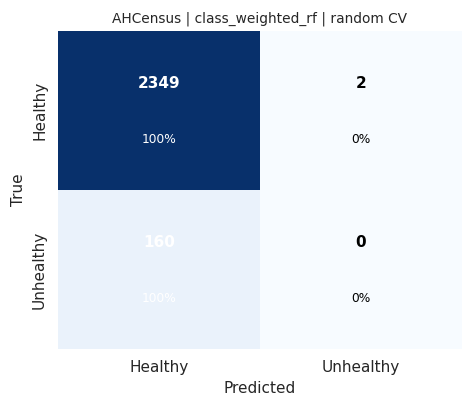

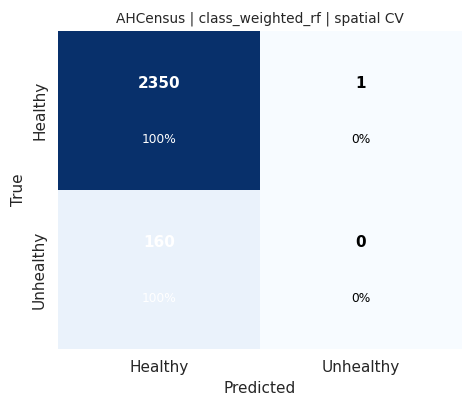

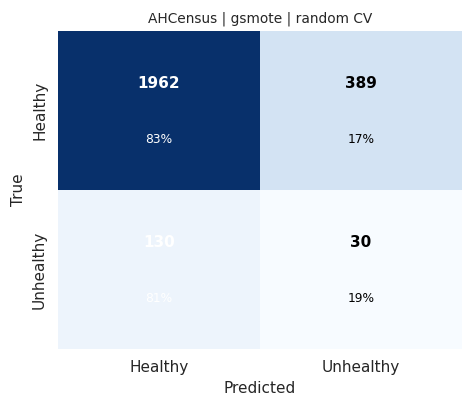

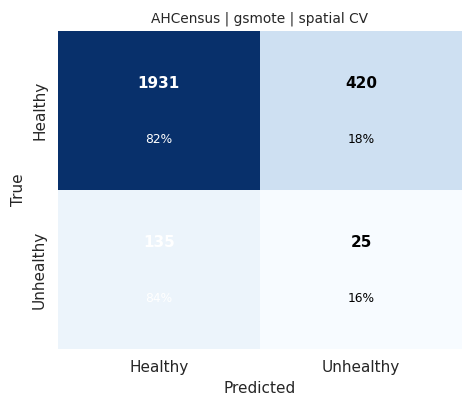

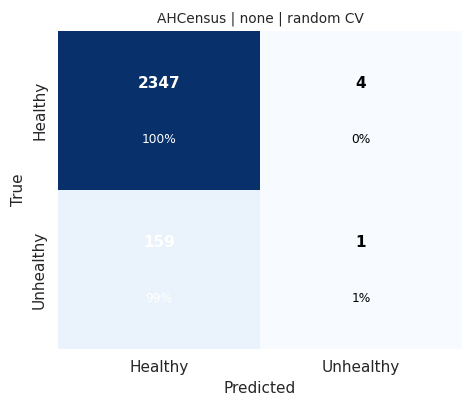

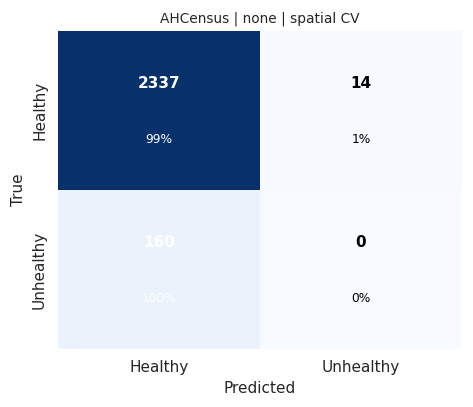

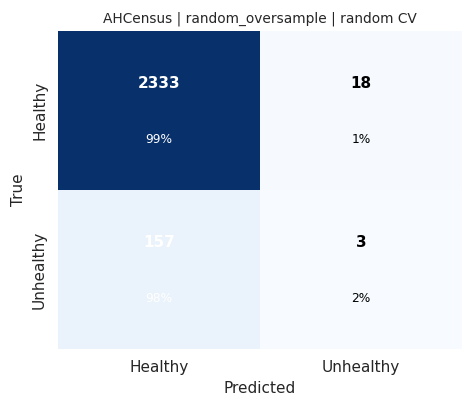

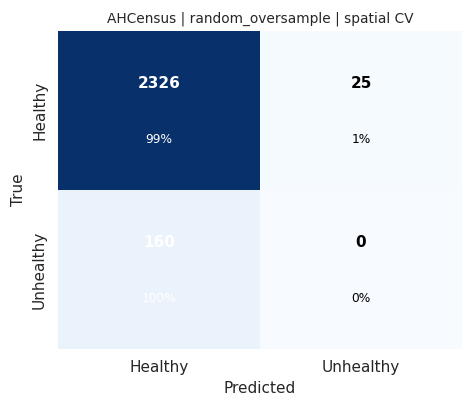

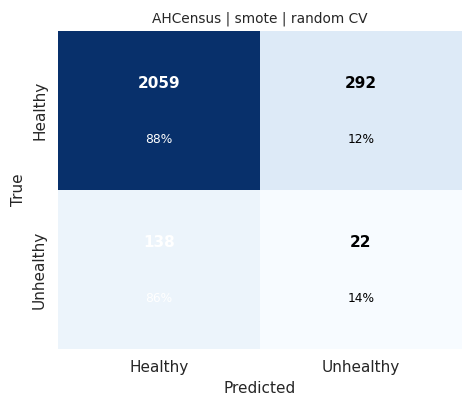

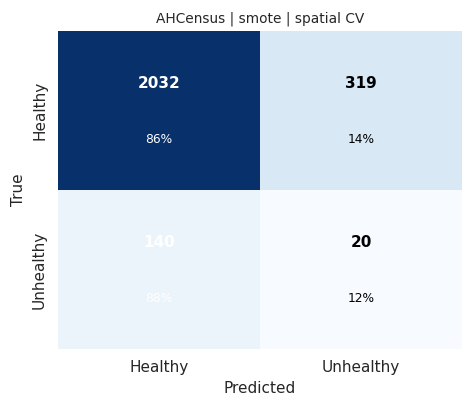

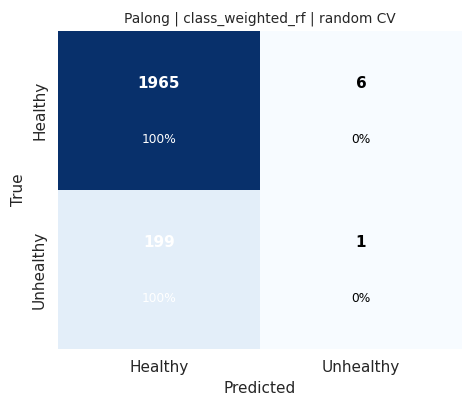

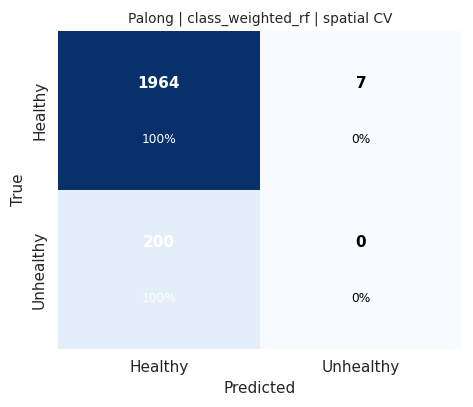

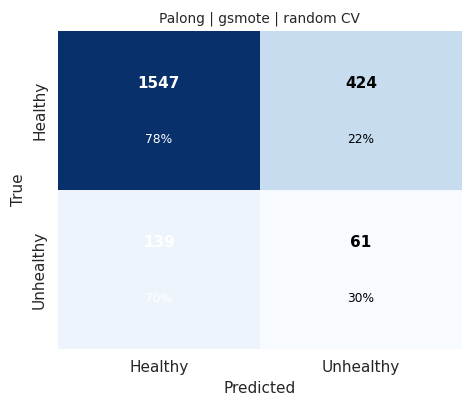

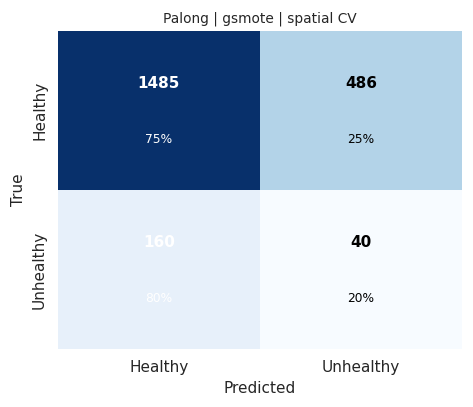

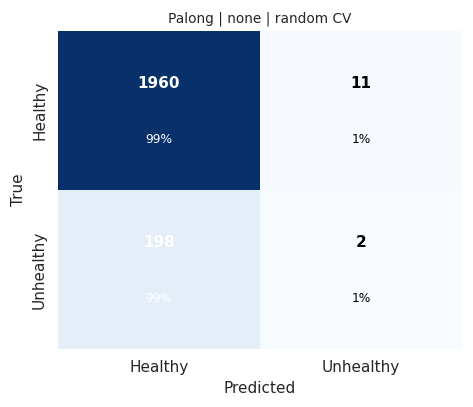

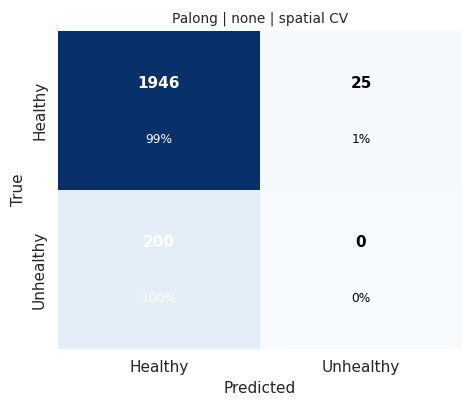

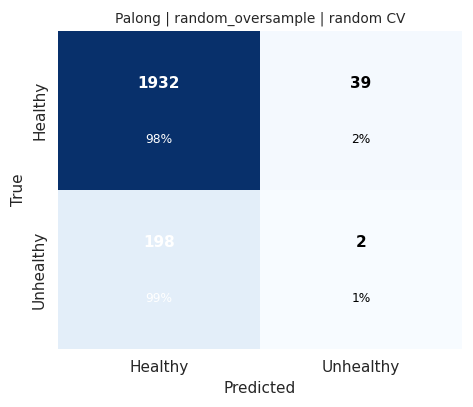

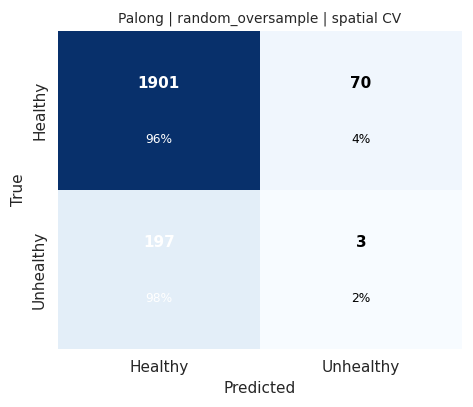

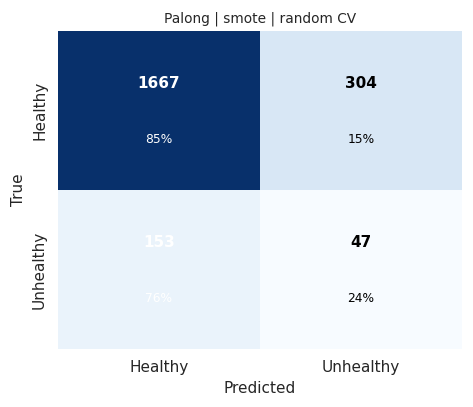

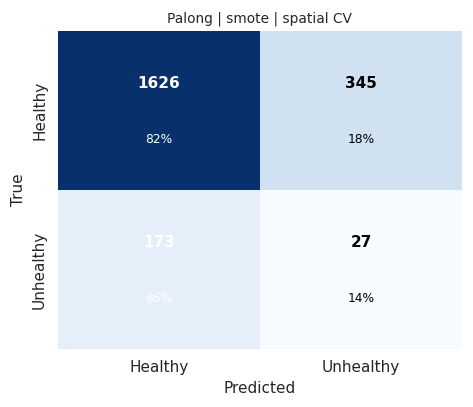

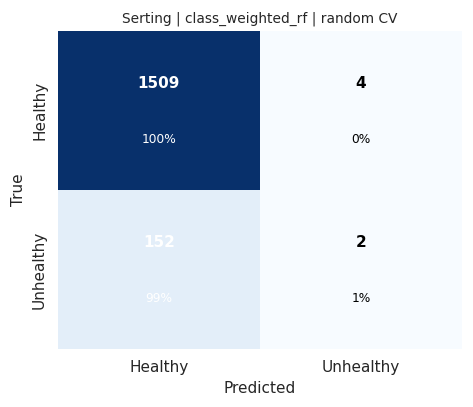

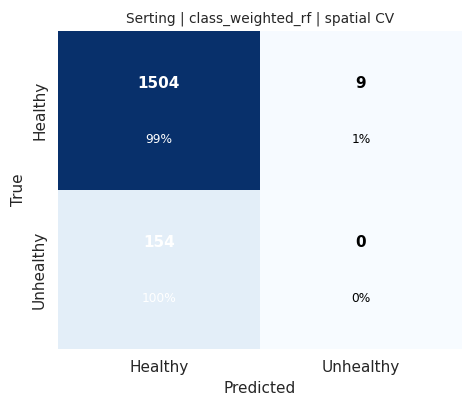

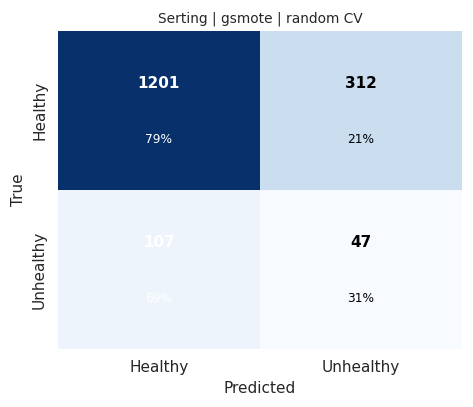

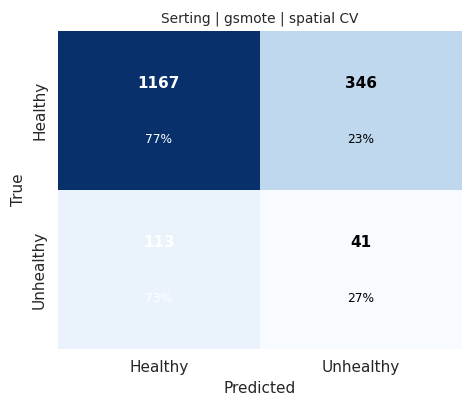

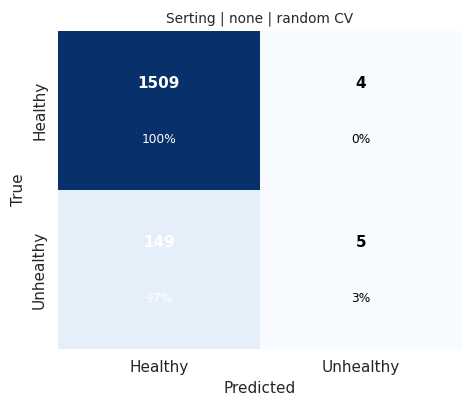

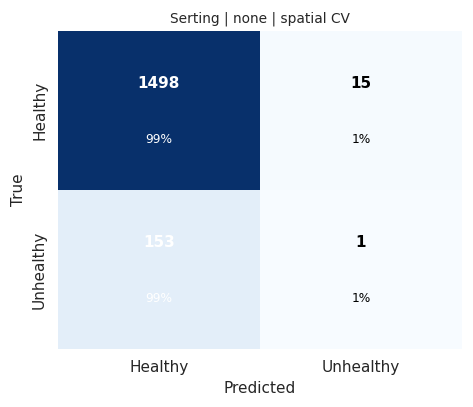

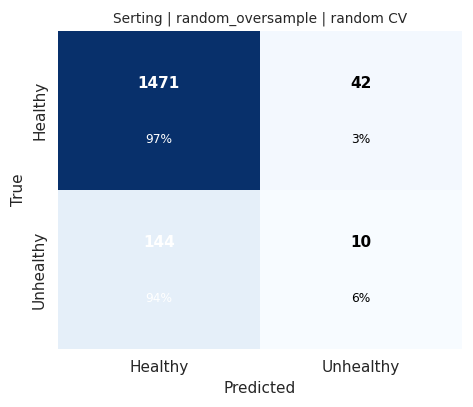

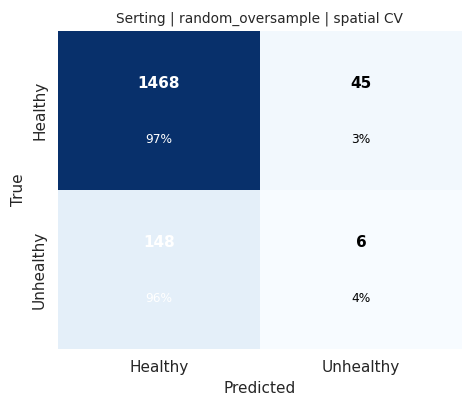

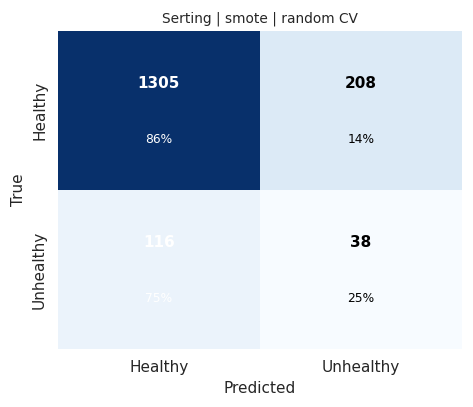

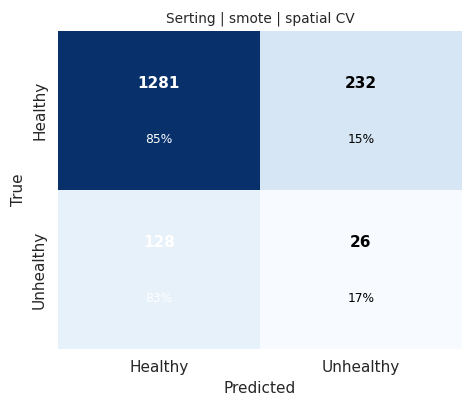

In [16]:
# =========================== 8.1 confusion matrices ===========================
CLASS_LABELS = ["Healthy", "Unhealthy"]


def plot_cm(y, yhat, path, title, labels=CLASS_LABELS):
    cm = confusion_matrix(y, yhat, labels=[0, 1])
    cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(figsize=(4.4, 3.8))
    sns.heatmap(cm, annot=False, cmap="Blues", cbar=False, ax=ax,
                xticklabels=labels, yticklabels=labels)
    for i in range(2):
        for j in range(2):
            col = "white" if cmn[i, j] > 0.5 else "black"
            ax.text(j + .5, i + .33, str(cm[i, j]), ha="center", va="center",
                    color=col, fontweight="bold")
            ax.text(j + .5, i + .68, f"{cmn[i, j] * 100:.0f}%", ha="center", va="center",
                    color=col, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title, fontsize=9)
    fig.tight_layout()
    fig.savefig(path, dpi=140)
    plt.show()
    plt.close(fig)


for (loc, sampler, cv_kind), res in sorted(OOF.items()):
    tag = loc.replace("_Basemap", "")
    plot_cm(res["y_true"], res["y_pred"],
            os.path.join(PLOTS_DIR, f"cm_{tag}_{sampler}_{cv_kind}.png"),
            f"{tag} | {sampler} | {cv_kind} CV")


ValueError: Input could not be cast to an at-least-1D NumPy array

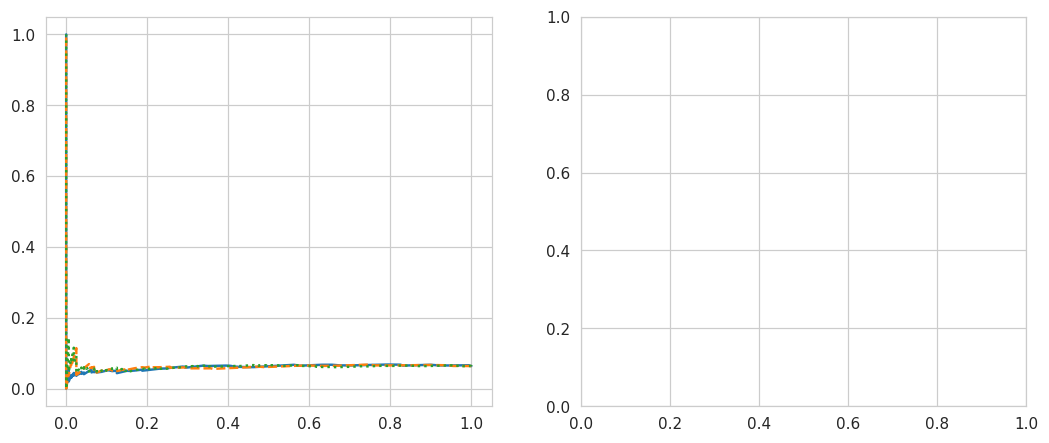

In [17]:
# =========================== 8.2 PR + ROC curves ===========================
_ARMS = [("none", "-"), ("class_weighted_rf", "--"), ("smote", ":"),
         ("random_oversample", (0, (3, 1, 1, 1))), ("gsmote", "-.")]

_CURVE_METRICS = {key: compute_metrics(res) for key, res in OOF.items()}

for loc in DATASETS_RAW:
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

    ax = axes[0]
    for sampler, ls in _ARMS:
        res = OOF.get((loc, sampler, "spatial"))
        if res is None:
            continue
        pr, rc, _ = precision_recall_curve(res["y_true"], res["y_prob"])
        ax.plot(rc, pr, ls, lw=1.6,
                label=f"{sampler}  AP={_CURVE_METRICS[(loc, sampler, 'spatial')]['pr_auc']:.3f}")
    ax.axhline(float((DATASETS_RAW[loc]["Class"] == POSITIVE_CLASS).mean()), color="grey",
               lw=1, ls="--", label="no-skill")
    ax.set_xlabel("Recall (Unhealthy)")
    ax.set_ylabel("Precision (Unhealthy)")
    ax.set_title(f"{loc} - precision-recall (spatial CV)")
    ax.legend(fontsize=7)

    ax = axes[1]
    for sampler, ls in _ARMS:
        res = OOF.get((loc, sampler, "spatial"))
        if res is None:
            continue
        fpr, tpr, _ = roc_curve(res["y_true"], res["y_prob"])
        ax.plot(fpr, tpr, ls, lw=1.6,
                label=f"{sampler}  AUC={_CURVE_METRICS[(loc, sampler, 'spatial')]['roc_auc']:.3f}")
    ax.plot([0, 1], [0, 1], color="grey", lw=1, ls="--", label="chance")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{loc} - ROC (spatial CV)")
    ax.legend(fontsize=7)

    fig.suptitle(f"{loc} - out-of-fold curves, honest spatial CV", y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(PLOTS_DIR, f"curves_{loc}.png"), dpi=140, bbox_inches="tight")
    plt.show()
    plt.close(fig)


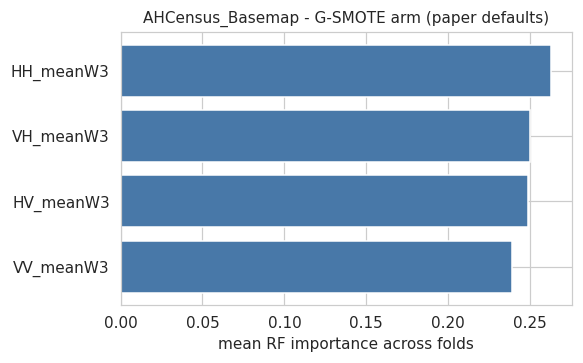

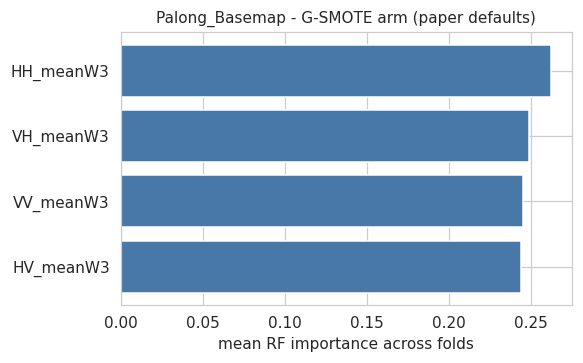

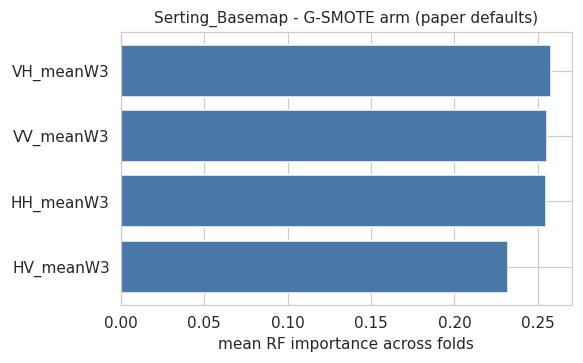

In [18]:
# =========================== 8.3 RF feature importance ===========================
for loc in DATASETS_RAW:
    res = OOF.get((loc, "gsmote", "spatial")) or OOF.get((loc, "gsmote", "random"))
    if res is None:
        continue
    order = np.argsort(res["importances"])[::-1]
    fig, ax = plt.subplots(figsize=(5.4, 0.45 * len(res["features"]) + 1.6))
    ax.barh([res["features"][i] for i in order][::-1],
            [res["importances"][i] for i in order][::-1], color="#4878a8")
    ax.set_xlabel("mean RF importance across folds")
    ax.set_title(f"{loc} - G-SMOTE arm (paper defaults)", fontsize=10)
    fig.tight_layout()
    fig.savefig(os.path.join(PLOTS_DIR, f"importance_{loc}.png"), dpi=140)
    plt.show()
    plt.close(fig)


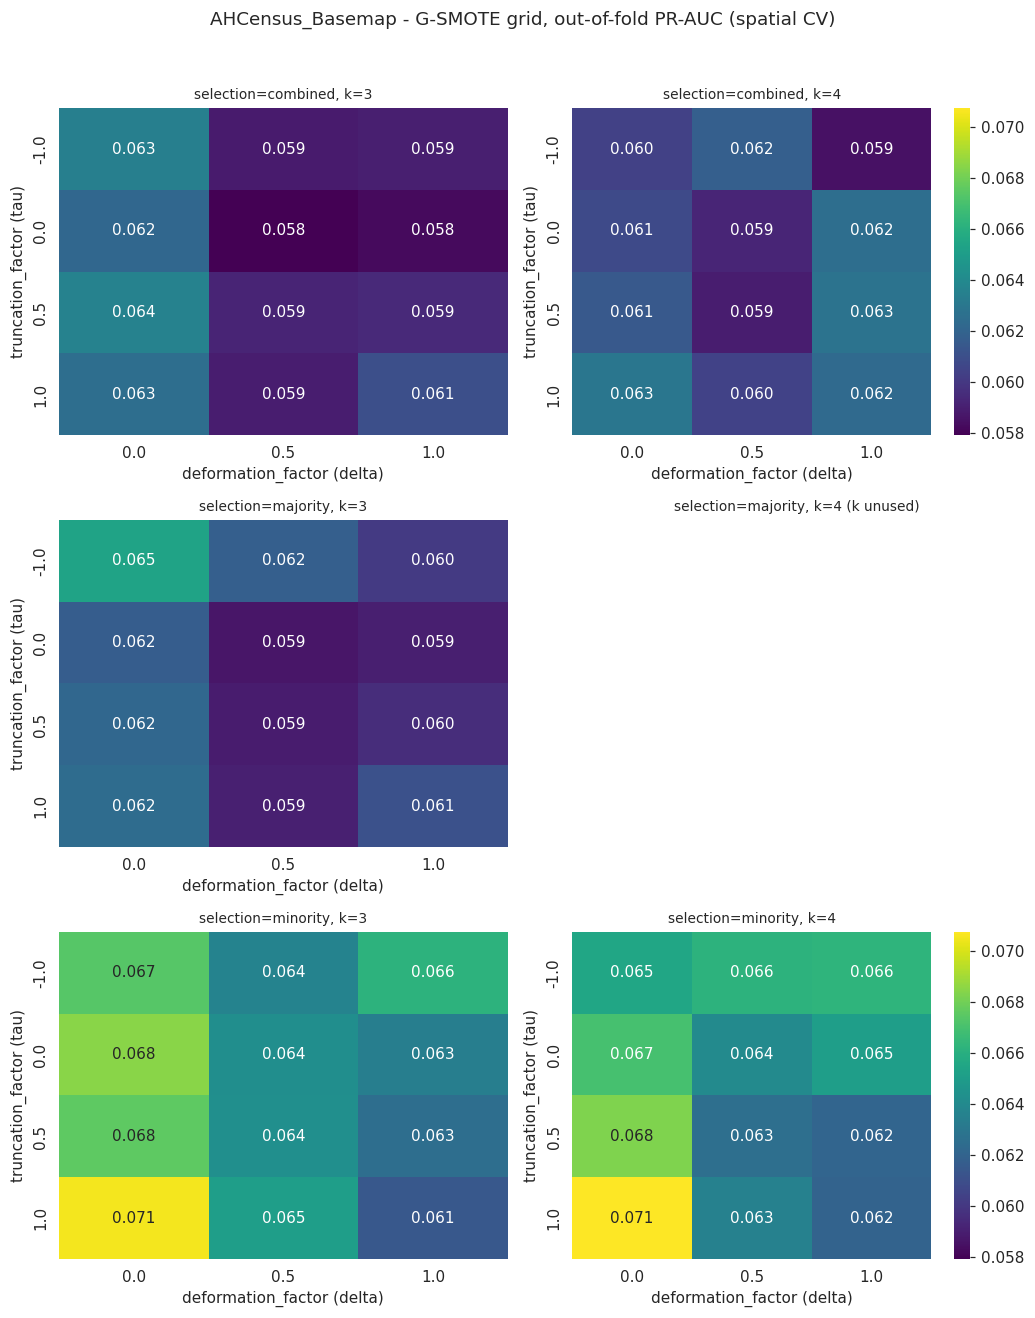

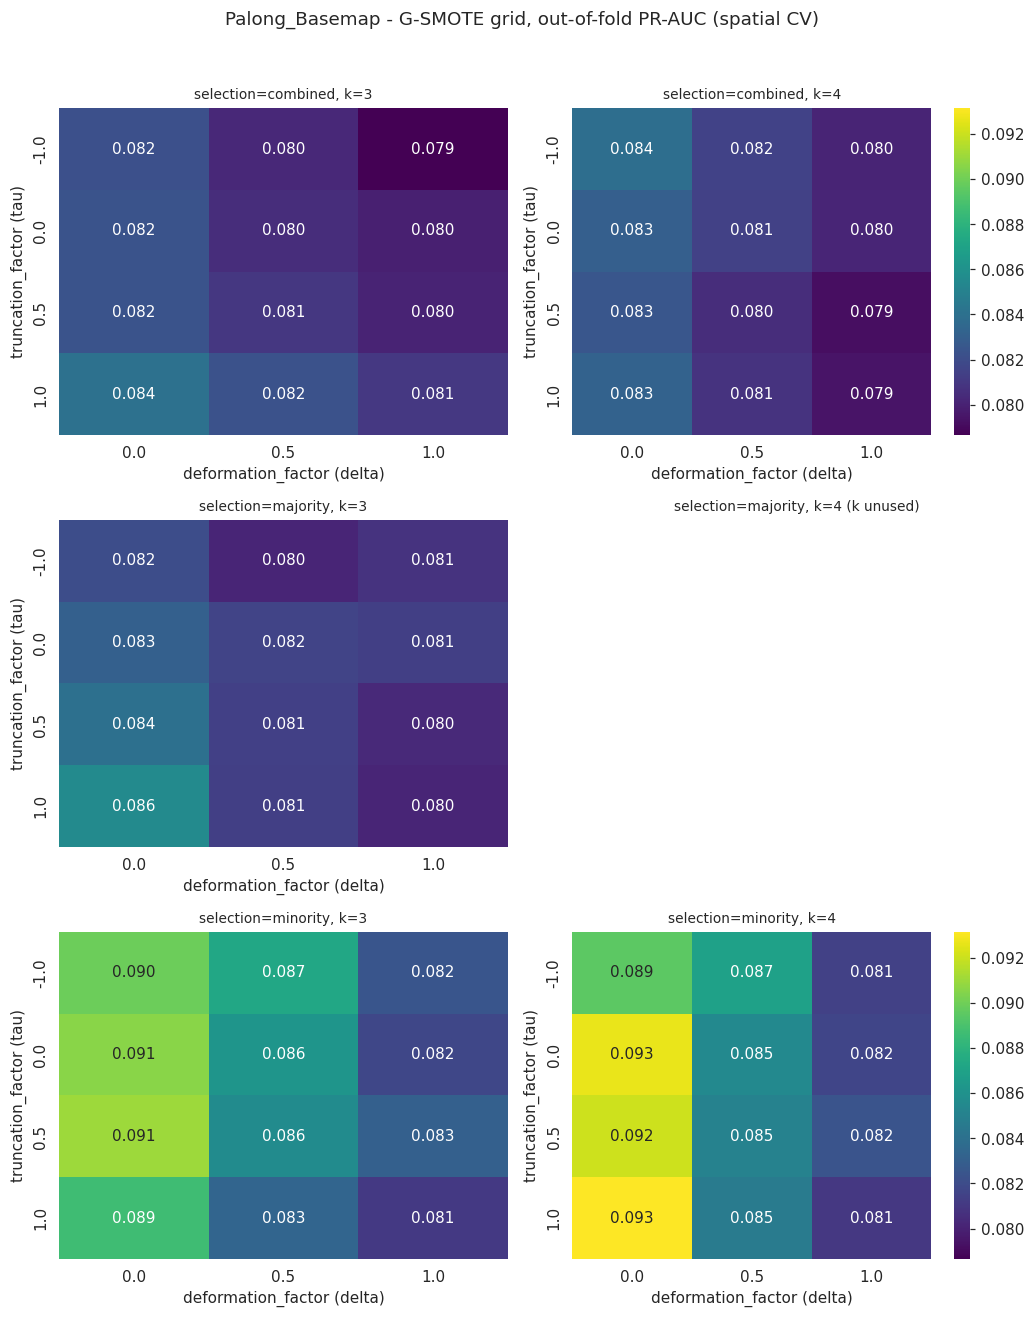

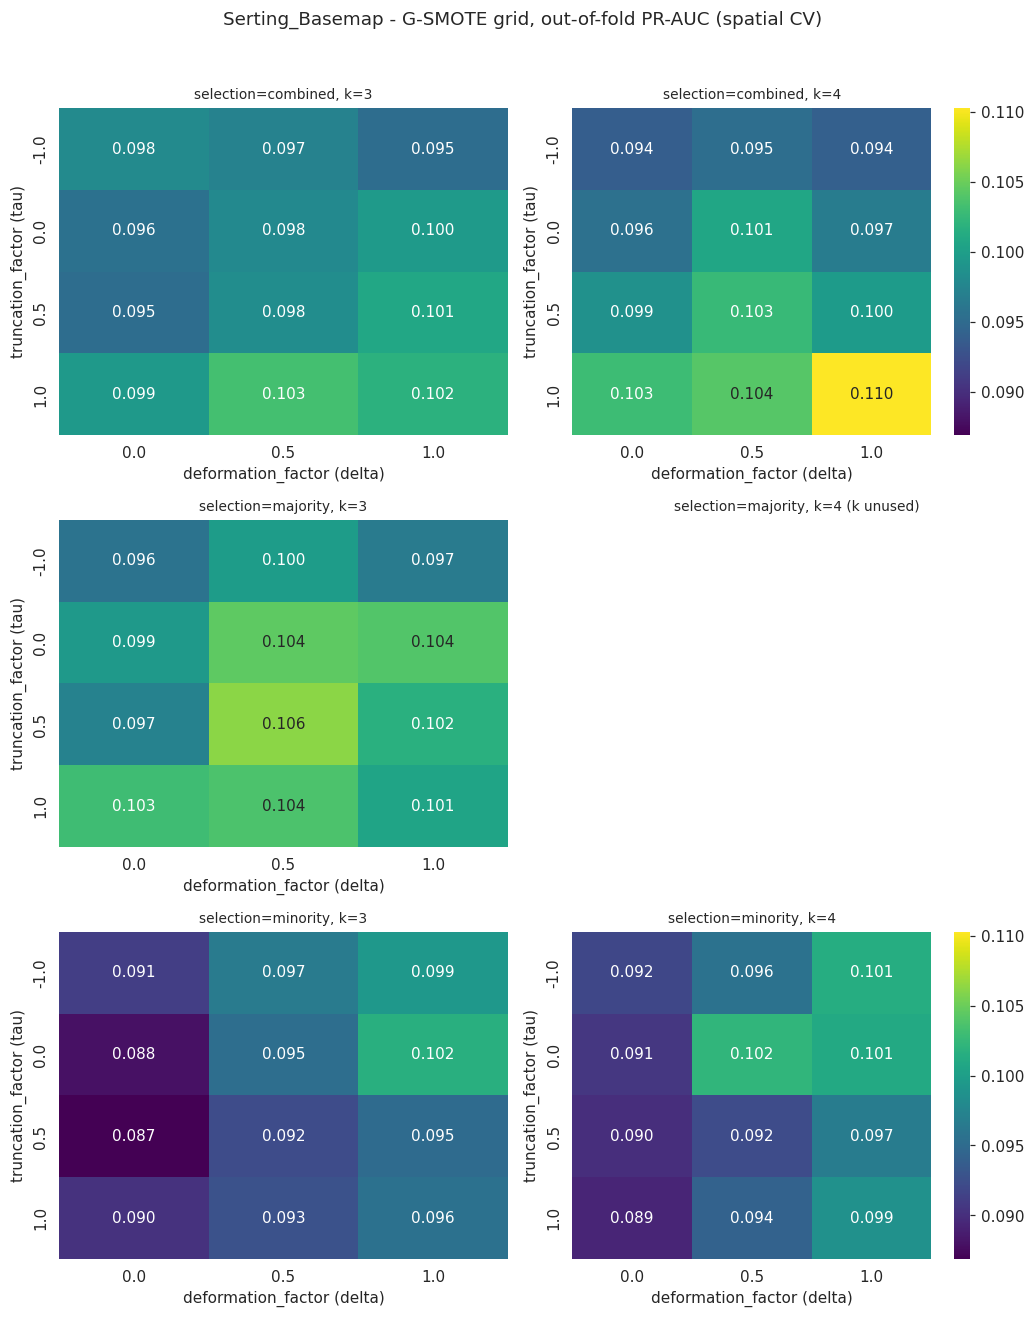

In [19]:
# =========================== 8.4 G-SMOTE sweep surface ===========================
if len(sweep_df):
    for loc in DATASETS_RAW:
        sub = sweep_df[sweep_df.location == loc]
        sels = sorted(sub["gsmote_selection_strategy"].unique())
        ks = sorted(sub["gsmote_k_neighbors"].unique())
        taus = sorted(sub["gsmote_truncation_factor"].unique())
        deltas = sorted(sub["gsmote_deformation_factor"].unique())

        fig, axes = plt.subplots(len(sels), len(ks),
                                 figsize=(4.8 * len(ks), 3.9 * len(sels)), squeeze=False)
        for r, sel in enumerate(sels):
            for c, k in enumerate(ks):
                ax = axes[r][c]
                cell = sub[(sub.gsmote_selection_strategy == sel) &
                           (sub.gsmote_k_neighbors == k)]
                if cell.empty:
                    # k is not part of the 'majority' mechanism, so that panel was
                    # deliberately not re-run as a duplicate
                    ax.axis("off")
                    ax.set_title(f"selection={sel}, k={k} (k unused)", fontsize=9)
                    continue
                grid = (cell.pivot_table(index="gsmote_truncation_factor",
                                         columns="gsmote_deformation_factor",
                                         values="pr_auc")
                            .reindex(index=taus, columns=deltas))
                sns.heatmap(grid, annot=True, fmt=".3f", cmap="viridis", ax=ax,
                            cbar=(c == len(ks) - 1), vmin=sub["pr_auc"].min(),
                            vmax=sub["pr_auc"].max())
                ax.set_title(f"selection={sel}, k={k}", fontsize=9)
                ax.set_xlabel("deformation_factor (delta)")
                ax.set_ylabel("truncation_factor (tau)")
        fig.suptitle(f"{loc} - G-SMOTE grid, out-of-fold PR-AUC (spatial CV)", y=1.02)
        fig.tight_layout()
        fig.savefig(os.path.join(PLOTS_DIR, f"gsmote_grid_{loc}.png"), dpi=140,
                    bbox_inches="tight")
        plt.show()
        plt.close(fig)


---
## 9. Summary and artifacts


In [20]:
# =========================== 9.1 summary.json ===========================
_EXCLUDED = ([f"{i}_meanW{w}" for i in ("RVI", "RFDI", "RFDI_VH") for w in WINDOWS]
             + [f"{p}{b}_meanW{w}"
                for p, bl in (("HA_", HA_BANDS), ("YA_", YA_BANDS))
                for b in bl for w in WINDOWS])

summary = {
    "notebook": "POC_AHCensus_RF_GSMOTE",
    "generated": time.strftime("%Y-%m-%d %H:%M:%S"),
    "gcs": {"bucket": GCS_BUCKET, "scene": SCENE_NAME,
            "label_uris": {l: LABEL_PATHS[l] for l in LABEL_PATHS}},
    "protocol": {
        "estates_modelled_independently": list(DATASETS_RAW.keys()),
        "classes_kept": CLASSES_KEPT, "positive_class": POSITIVE_CLASS,
        "windows": WINDOWS, "features": FEATURES + EXTRA_FEATURES,
        "excluded_from_features": {
            "columns": _EXCLUDED,
            "reason": "kept in the dataset CSV for future Polarized-RVI work; not model inputs",
        },
        "rf_params": RF_PARAMS, "seed": SEED, "n_splits": N_SPLITS,
        "block_deg": BLOCK_DEG, "spatial_splitter": SPATIAL_SPLITTER,
        "spatial_buffer_m": SPATIAL_BUFFER_M,
        "cv": {"spatial": "GroupKFold on ~220 m blocks (honest)",
               "random": "StratifiedKFold (leakage ceiling)"},
    },
    "gsmote": {
        "backend": GSMOTE_BACKEND,
        "reference_package": "imbalanced-learn-extra",
        "reference_available": bool(HAVE_REFERENCE_GSMOTE),
        "install_succeeded": bool(globals().get("GSMOTE_INSTALL_OK", False)),
        "citation": ("Douzas, G. & Bacao, F. (2019). Geometric SMOTE: a geometrically "
                     "enhanced drop-in replacement for SMOTE. Information Sciences 501, "
                     "118-135. doi:10.1016/j.ins.2019.06.007"),
        "defaults_used_in_baselines": GSMOTE_PAPER_DEFAULT,
        "swept_grid": GSMOTE_SWEEP,
        "invariants": {k: {n: ok for n, ok in v} for k, v in GSMOTE_INVARIANTS.items()},
    },
    "raster_meta": RASTER_META,
    "sampling_sanity": sanity_df.to_dict(orient="records"),
    "baseline_metrics": json.loads(baseline_df.to_json(orient="records")),
}
if len(sweep_df):
    summary["gsmote_sweep"] = {
        "n_configurations": int(len(SWEEP_COMBOS)),
        "best_per_estate": json.loads(
            sweep_df.sort_values("pr_auc", ascending=False)
                     .groupby("location", as_index=False).head(1).to_json(orient="records")),
        "spread_per_estate": json.loads(
            sweep_df.groupby("location")["pr_auc"].agg(["mean", "std", "min", "max"])
                     .round(4).reset_index().to_json(orient="records")),
        "note": ("the sweep is a selection surface; the unbiased headline is the fixed "
                 "paper-default configuration in baseline_metrics.csv"),
    }

with open(os.path.join(RESULTS_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2, default=str)
print("summary.json written")

print("\n=== artifacts in", RESULTS_DIR, "===")
for p in sorted(glob.glob(os.path.join(RESULTS_DIR, "**", "*"), recursive=True)):
    if os.path.isfile(p):
        print(f"  {os.path.relpath(p, RESULTS_DIR):50s} {os.path.getsize(p) / 1024:8.1f} KB")


summary.json written

=== artifacts in /content/SAR-OilPalm/data/processed/poc_ahcensus_rf_gsmote ===
  baseline_metrics.csv                                   11.8 KB
  dataset_AHCensus_Basemap.csv                          505.0 KB
  dataset_Palong_Basemap.csv                            441.0 KB
  dataset_Serting_Basemap.csv                           339.7 KB
  dataset_all_estates.csv                              1285.3 KB
  gsmote_sweep_spatial.csv                               90.1 KB
  gsmote_sweep_spatial_AHCensus_Basemap.csv              30.0 KB
  gsmote_sweep_spatial_Palong_Basemap.csv                29.6 KB
  gsmote_sweep_spatial_Serting_Basemap.csv               31.1 KB
  gsmote_sweep_top_random.csv                             7.8 KB
  plots/cm_AHCensus_class_weighted_rf_random.png         24.9 KB
  plots/cm_AHCensus_class_weighted_rf_spatial.png        24.8 KB
  plots/cm_AHCensus_gsmote_random.png                    24.7 KB
  plots/cm_AHCensus_gsmote_spatial.png               

---
## 10. How to read the results

- **Trust the `spatial` rows.** The `random` rows are a leakage ceiling: disease labels are
  spatially contiguous (~89% of trees share their nearest neighbour's label at ~8 m spacing), so a
  random split leaks neighbouring trees between train and test and inflates every metric.
- **PR-AUC, not accuracy.** The positive rate is ~6-9%, so `pr_auc_baseline` is the no-skill
  precision. A PR-AUC close to that baseline means the model is not ranking diseased trees above
  healthy ones.
- **G-SMOTE attribution.** Compare `gsmote` against `class_weighted_rf` and
  `random_oversample`: all three hand the RandomForest a balanced training set, so any gap comes
  from *where the synthetic points are placed*, not from balancing.
- **The sweep is a surface, not a score.** Selecting the best of 72 configurations on the same
  out-of-fold metric is optimistically biased by construction. The honest headline is the fixed
  paper-default configuration; the sweep shows how sensitive the result is to tau / delta /
  selection strategy, which is itself a useful finding.
- **AHCensus is the point of this run.** Palong and Serting are kept as references, but their
  labels were derived/estimated. AHCensus is measured ground truth, so if a per-tree SAR signature
  exists at all in this scene, AHCensus is where it should show up.
- **If G-SMOTE does not lift honest PR-AUC**, that is consistent with the MeanSampling report: the
  per-tree, single-date, intensity-level cue is weak, and single-date SAR is at its information
  ceiling for this target - which is exactly why this notebook also starts banking the
  polarimetric means for the Polarized-RVI direction.
